 # **Milestone 2: Data Visualization on Machine Learning Solution Project**



---



Milestone 2 requires you to generate data visualizations of your Milestone 1 using Matplotlib and Seaborn.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

## **Customer Demographics**


---


Columns:
* **CustomerID**: Unique identifier for each customer.
* **Age**: Numerical value representing the age of the customer.
* **Gender**: Categorical value indicating the gender of the customer.
* **Location**: Categorical value representing the geographic location of the customer.
* **IncomeLevel**: Categorical or numerical representation of the customer's income level.
* **SignupDate**: Date representing when the customer registered or signed up.



In [ ]:
import pandas as pd

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

### **Age Distribution**

Analyze how customers are distributed across different age groups.

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Assuming the customer demographics dataset is already loaded into 'customer_demographics'
# Sample dataset 'customer_demographics' contains 'Age' column.

# Define the age groups and corresponding labels
age_bins = [0, 12, 19, 39, 59, 99]
age_labels = ['Babies/Children (0-12)', 'Teens (13-19)', 'Young Adults (20-39)', 'Middle-aged Adults (40-59)', 'Old Adults (60-99)']

# Group data by AgeGroup to count the number of customers in each category
age_group_counts = customer_demographics['AgeGroup'].value_counts().reindex(age_labels)

# Create a bar chart using Plotly
# Pass the index directly as df.index for x-axis
fig = px.bar(
    age_group_counts,  # Use age_group_counts directly
    x=age_group_counts.index,  # Use .index to access the age group labels
    y=age_group_counts.values,  # Use .values to access the count data for the y-axis
    labels={'x': 'Age Group', 'y': 'Number of Customers'}, # Changed 'AgeGroup' to 'y'
    title='Customer Distribution by Age Group',
    color=age_group_counts.index,  # Using color based on Age Group categories
    color_discrete_sequence=px.colors.qualitative.Set2  # Similar palette to Seaborn 'Set2'
)



# Rotate x-axis labels for readability
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()

### **Gender Distribution**

In [ ]:
import plotly.express as px

# Define a custom color palette (e.g., shades of blue for better contrast)
custom_colors = ['#c90076', '#2986cc']  # Example: Blue for Male, Orange for Female

# Create a donut chart with the custom color palette
fig = px.pie(customer_demographics,
             names='Gender',
             title='Customer Gender Distribution',
             hole=0.4,  # This creates the hole for a donut chart
             labels={'Gender': 'Gender'},
             color_discrete_sequence=custom_colors)  # Apply custom colors

# Update the text to include both the percentage and the actual count inside the segments
fig.update_traces(textinfo='percent+label',  # Show both percentage and label (Male/Female)
                  hoverinfo='label+percent+value',  # Show label, percent, and actual count on hover
                  textposition='inside')  # Place text inside the donut

# Show the chart
fig.show()


### **Customer Signup Trends Over Time**

In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original customer demographics data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format (allowing for different date formats using 'mixed')
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year from the 'SignupDate' column and store it in a new 'SignupYear' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year

# Extract the month name from the 'SignupDate' column and store it in a new 'SignupMonth' column
cust_demo2['SignupMonth'] = cust_demo2['SignupDate'].dt.month_name()

# Group the data by 'SignupYear' and 'SignupMonth', counting the number of signups per year-month
signup = cust_demo2.groupby(['SignupYear', 'SignupMonth']).size()

# Reset the index of the resulting grouped data to create a dataframe, and rename the count column to 'Count'
signup = signup.reset_index(name='Count')

# Create a 'YearMonth' column by concatenating 'SignupYear' and 'SignupMonth' for better grouping
signup['YearMonth'] = signup['SignupYear'].astype(str) + '-' + signup['SignupMonth'].astype(str)

# Sort the dataframe by YearMonth for a chronological line plot
signup['YearMonth'] = pd.to_datetime(signup['YearMonth'], format='%Y-%B')
signup = signup.sort_values(by='YearMonth')

# Convert 'YearMonth' back to string format for displaying in the plot
signup['YearMonth'] = signup['YearMonth'].dt.strftime('%Y-%B')

# Identify the highest and lowest points
max_signup = signup[signup['Count'] == signup['Count'].max()]
min_signup = signup[signup['Count'] == signup['Count'].min()]

# Create an interactive line plot using Plotly
fig = px.line(signup, x='YearMonth', y='Count',
              title='Signups Over Time',
              labels={'YearMonth': 'Year-Month', 'Count': 'Total Signups'},
              markers=True)

# Add markers for highest point (blue) with detailed label
fig.add_scatter(x=max_signup['YearMonth'], y=max_signup['Count'], mode='markers+text',
                marker=dict(size=12, color='blue', symbol='circle'),
                text=[f"Highest: {max_signup['YearMonth'].values[0]}, {max_signup['Count'].values[0]}"],
                textposition='top center',
                name='Highest')

# Add markers for lowest point (grey) with detailed label
fig.add_scatter(x=min_signup['YearMonth'], y=min_signup['Count'], mode='markers+text',
                marker=dict(size=12, color='grey', symbol='circle'),
                text=[f"Lowest: {min_signup['YearMonth'].values[0]}, {min_signup['Count'].values[0]}"],
                textposition='bottom center',
                name='Lowest')

# Improve layout for better readability and spacing of x-axis labels
fig.update_layout(
    xaxis_title='Year-Month',
    yaxis_title='Total Signups',
    xaxis_tickangle=-45,
    xaxis=dict(
        tickmode='array',
        tickvals=signup['YearMonth'][::3],  # Show every 3rd month to reduce clutter
        ticktext=signup['YearMonth'][::3]
    ),
    template='plotly_white'
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original customer demographics data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format (allowing for different date formats using 'mixed')
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year from the 'SignupDate' column and store it in a new 'SignupYear' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year

# Extract the month name from the 'SignupDate' column and store it in a new 'SignupMonth' column
cust_demo2['SignupMonth'] = cust_demo2['SignupDate'].dt.month_name()

# Group the data by 'SignupYear' and 'SignupMonth', counting the number of signups per year-month
signup = cust_demo2.groupby(['SignupYear', 'SignupMonth']).size()

# Reset the index of the resulting grouped data to create a dataframe, and rename the count column to 'Count'
signup = signup.reset_index(name='Count')

# Create a 'YearMonth' column by concatenating 'SignupYear' and 'SignupMonth' for better grouping
signup['YearMonth'] = signup['SignupYear'].astype(str) + '-' + signup['SignupMonth'].astype(str)

# Sort the dataframe by YearMonth for a chronological line plot
signup['YearMonth'] = pd.to_datetime(signup['YearMonth'], format='%Y-%B')
signup = signup.sort_values(by='YearMonth')

# Convert 'YearMonth' back to string format for displaying in the plot
signup['YearMonth'] = signup['YearMonth'].dt.strftime('%Y-%B')

# Identify the highest and lowest points
max_signup = signup[signup['Count'] == signup['Count'].max()]
min_signup = signup[signup['Count'] == signup['Count'].min()]

# Calculate the average signups per month
average_signups = signup['Count'].mean()

# Create an interactive line plot using Plotly
fig = px.line(signup, x='YearMonth', y='Count',
              title='Signups Over Time with Average Line',
              labels={'YearMonth': 'Year-Month', 'Count': 'Total Signups'},
              markers=True)

# Add markers for highest point (blue) with detailed label
fig.add_scatter(x=max_signup['YearMonth'], y=max_signup['Count'], mode='markers+text',
                marker=dict(size=12, color='blue', symbol='circle'),
                text=[f"Highest: {max_signup['YearMonth'].values[0]}, {max_signup['Count'].values[0]}"],
                textposition='top center',
                name='Highest')

# Add markers for lowest point (grey) with detailed label
fig.add_scatter(x=min_signup['YearMonth'], y=min_signup['Count'], mode='markers+text',
                marker=dict(size=12, color='grey', symbol='circle'),
                text=[f"Lowest: {min_signup['YearMonth'].values[0]}, {min_signup['Count'].values[0]}"],
                textposition='bottom center',
                name='Lowest')

# Add a horizontal line for the average signups, with green label
fig.add_hline(y=average_signups, line_dash="dash", line_color="green",
              annotation_text=f"Average: {average_signups:.2f}",
              annotation_position="bottom right",
              annotation_font_color="green")

# Improve layout for better readability and spacing of x-axis labels
fig.update_layout(
    xaxis_title='Year-Month',
    yaxis_title='Total Signups',
    xaxis_tickangle=-45,
    xaxis=dict(
        tickmode='array',
        tickvals=signup['YearMonth'][::3],  # Show every 3rd month to reduce clutter
        ticktext=signup['YearMonth'][::3]
    ),
    template='plotly_white'
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Assuming the customer demographics data is loaded and processed as before
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year from the 'SignupDate' column and store it in a new 'SignupYear' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year

# Group the data by 'SignupYear' to calculate the total number of signups per year
yearly_signup = cust_demo2.groupby('SignupYear').size().reset_index(name='YearlySignups')

# Create a custom color scale that starts with solid blue and gets darker
custom_color_scale = [
    [0.0, "rgb(70,130,180)"],  # Light steel blue
    [0.5, "rgb(0,0,205)"],     # Medium blue
    [1.0, "rgb(0,0,139)"]      # Dark blue
]

# Create a bar plot using Plotly
fig = px.bar(yearly_signup, x='SignupYear', y='YearlySignups',
             title='Yearly Signups',
             labels={'SignupYear': 'Signup Year', 'YearlySignups': 'Total Signups'},
             color='YearlySignups',  # Color based on total signups for visual effect
             color_continuous_scale=custom_color_scale)

# Add text labels on top of each bar for the count of yearly signups
fig.update_traces(
    text=yearly_signup['YearlySignups'],
    textposition='outside'  # Position text outside the top of the bar for clarity
)

# Update layout for better readability and improved colors
fig.update_layout(
    xaxis_title='Signup Year',
    yaxis_title='Total Signups',
    template='plotly_white',
    coloraxis_colorbar=dict(title='Signups Count'),
    plot_bgcolor='#f8f8f8'  # Set a light grey background to contrast better
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year and quarter from the 'SignupDate' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year
cust_demo2['SignupQuarter'] = cust_demo2['SignupDate'].dt.quarter

# Convert 'SignupQuarter' to a string to ensure discrete coloring
cust_demo2['SignupQuarter'] = cust_demo2['SignupQuarter'].astype(str)

# Group the data by 'SignupYear' and 'SignupQuarter', counting the number of signups per quarter
quarterly_signup = cust_demo2.groupby(['SignupYear', 'SignupQuarter']).size().reset_index(name='TotalSignups')

# Define the custom color palette
custom_colors = ['#dabfff', '#907ad6', '#4f518c', '#2c2a4a']

# Create a vertical grouped bar plot using the custom discrete colors
fig = px.bar(quarterly_signup, x='SignupYear', y='TotalSignups',
             color='SignupQuarter', barmode='group',
             title='Quarterly Signups by Year',
             labels={'SignupYear': 'Signup Year', 'TotalSignups': 'Total Signups', 'SignupQuarter': 'Quarter'},
             color_discrete_sequence=custom_colors)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Signup Year',
    yaxis_title='Total Signups',
    template='plotly_white',
    legend_title='Quarter'
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year and quarter from the 'SignupDate' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year
cust_demo2['SignupQuarter'] = cust_demo2['SignupDate'].dt.quarter

# Convert 'SignupQuarter' to a string to ensure discrete coloring and maintain order
cust_demo2['SignupQuarter'] = 'Q' + cust_demo2['SignupQuarter'].astype(str)

# Group the data by 'SignupYear' and 'SignupQuarter', counting the number of signups per quarter
quarterly_signup = cust_demo2.groupby(['SignupYear', 'SignupQuarter']).size().reset_index(name='TotalSignups')

# Sort by SignupYear and then by SignupQuarter (to ensure Q1, Q2, Q3, Q4 order)
quarterly_signup = quarterly_signup.sort_values(by=['SignupYear', 'SignupQuarter'])

# Define the custom color palette
custom_colors = ['#dabfff', '#907ad6', '#4f518c', '#2c2a4a']

# Create a vertical grouped bar plot using the custom discrete colors
fig = px.bar(quarterly_signup, x='SignupYear', y='TotalSignups',
             color='SignupQuarter', barmode='group',
             title='Quarterly Signups by Year',
             labels={'SignupYear': 'Signup Year', 'TotalSignups': 'Total Signups', 'SignupQuarter': 'Quarter'},
             category_orders={'SignupQuarter': ['Q1', 'Q2', 'Q3', 'Q4']},  # Ensure Q1, Q2, Q3, Q4 order
             color_discrete_sequence=custom_colors)

# Identify the highest and lowest signup quarters for each year
max_signup = quarterly_signup.loc[quarterly_signup.groupby('SignupYear')['TotalSignups'].idxmax()]
min_signup = quarterly_signup.loc[quarterly_signup.groupby('SignupYear')['TotalSignups'].idxmin()]

# Define fixed y positions for the annotations
highest_y_position = 170  # Increased top line for highest
lowest_y_position = 150   # Increased line for lowest

# Add annotations for the highest and lowest quarters
for index, row in max_signup.iterrows():
    fig.add_annotation(
        x=row['SignupYear'],  # Align with the year
        y=highest_y_position,  # Increased top line for highest
        text=f"Highest for {row['SignupYear']}: {row['SignupQuarter']} ({row['TotalSignups']})",  # Label text
        showarrow=False,  # Remove arrows
        yshift=0  # No additional offset needed
    )

for index, row in min_signup.iterrows():
    fig.add_annotation(
        x=row['SignupYear'],  # Align with the year
        y=lowest_y_position,  # Increased line for lowest
        text=f"Lowest for {row['SignupYear']}: {row['SignupQuarter']} ({row['TotalSignups']})",  # Label text
        showarrow=False,  # Remove arrows
        yshift=0  # No additional offset needed
    )

# Update layout for better readability
fig.update_layout(
    xaxis_title='Signup Year',
    yaxis_title='Total Signups',
    template='plotly_white',
    legend_title='Quarter'
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year and quarter from the 'SignupDate' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year
cust_demo2['SignupQuarter'] = cust_demo2['SignupDate'].dt.quarter

# Group the data by 'SignupYear' and 'SignupQuarter', counting the number of signups per quarter
quarterly_signup = cust_demo2.groupby(['SignupYear', 'SignupQuarter']).size().reset_index(name='TotalSignups')

# Calculate the average signups for each quarter across all years
average_signup_per_quarter = quarterly_signup.groupby('SignupQuarter')['TotalSignups'].mean().reset_index(name='AverageSignups')

# Convert 'SignupQuarter' to a string to ensure discrete coloring and maintain order
average_signup_per_quarter['SignupQuarter'] = 'Q' + average_signup_per_quarter['SignupQuarter'].astype(str)

# Create a bar chart to show the average signups per quarter across all years
fig = px.bar(average_signup_per_quarter, x='SignupQuarter', y='AverageSignups',
             title='Average Signups Per Quarter Across All Years',
             labels={'SignupQuarter': 'Quarter', 'AverageSignups': 'Average Signups'},
             color='SignupQuarter',  # Optional: color by quarter for better distinction
             color_discrete_sequence=['#dabfff', '#907ad6', '#4f518c', '#2c2a4a'])  # Custom colors

# Update layout for better readability
fig.update_layout(
    xaxis_title='Quarter',
    yaxis_title='Average Signups',
    template='plotly_white'
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics dataset from a CSV file
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Make a copy of the original data to preserve the original dataset
cust_demo2 = customer_demographics.copy()

# Convert the 'SignupDate' column to a datetime format
cust_demo2['SignupDate'] = pd.to_datetime(cust_demo2['SignupDate'], format='mixed')

# Extract the year and quarter from the 'SignupDate' column
cust_demo2['SignupYear'] = cust_demo2['SignupDate'].dt.year
cust_demo2['SignupQuarter'] = cust_demo2['SignupDate'].dt.quarter

# Convert 'SignupQuarter' to a string to ensure discrete coloring
cust_demo2['SignupQuarter'] = cust_demo2['SignupQuarter'].astype(str)

# Group the data by 'SignupQuarter', counting the total signups per quarter across all years
total_per_quarter = cust_demo2.groupby(['SignupQuarter']).size().reset_index(name='TotalSignups')

# Define the custom color palette
custom_colors = ['#dabfff', '#907ad6', '#4f518c', '#2c2a4a']

# Create a bar plot showing total signups per quarter
fig = px.bar(total_per_quarter, x='SignupQuarter', y='TotalSignups',
             color='SignupQuarter', title='Total Signups per Quarter Across All Years',
             labels={'SignupQuarter': 'Quarter', 'TotalSignups': 'Total Signups'},
             color_discrete_sequence=custom_colors)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Quarter',
    yaxis_title='Total Signups',
    template='plotly_white',
    legend_title='Quarter',
    showlegend=False  # Hide legend since the x-axis already describes the quarters
)

# Show the interactive plot
fig.show()


### **Income Level Distribution**

In [ ]:
import pandas as pd
import plotly.express as px

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Instead of using aggregator, directly calculate the counts using pandas and then plot
income_level_counts = customer_demographics['IncomeLevel'].value_counts().reset_index()
income_level_counts.columns = ['IncomeLevel', 'count']  # Rename columns for clarity

# Create a Plotly bar chart using the aggregated data
fig = px.bar(
    income_level_counts,  # Use the aggregated data
    x='IncomeLevel',
    y='count',  # Use the calculated counts
    title='Customer Distribution by Income Level',
    labels={'IncomeLevel': 'Income Level', 'count': 'Number of Customers'},
    color='IncomeLevel',  # Different colors for each income level
    color_discrete_sequence=px.colors.qualitative.Set2  # Similar palette to Seaborn's 'Set2'
)

# Show the chart
fig.show()

In [ ]:
import plotly.express as px

# Create a pie chart for the income level distribution
fig = px.pie(cust_demo2,
             names='IncomeLevel',  # Column for the segments (income levels)
             title='Customer Distribution by Income Level',  # Chart title
             hole=0.4,  # This creates a donut chart; set hole=0 if you want a regular pie chart
             labels={'IncomeLevel': 'Income Level'})  # Label for income level

# Update the text to show the percentage and count inside the pie chart
fig.update_traces(textinfo='percent+label',  # Show percentage and label (Income Level)
                  hoverinfo='label+percent+value',  # On hover, show label, percentage, and actual count
                  textposition='inside')  # Place text inside the pie segments

# Show the pie chart
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Create a dictionary to map each month to its corresponding quarter
month_to_quarter = {
    'January': 'Q1', 'February': 'Q1', 'March': 'Q1',
    'April': 'Q2', 'May': 'Q2', 'June': 'Q2',
    'July': 'Q3', 'August': 'Q3', 'September': 'Q3',
    'October': 'Q4', 'November': 'Q4', 'December': 'Q4'
}

# Assuming 'SignupDate' column contains date information, convert to datetime if needed
if not pd.api.types.is_datetime64_any_dtype(customer_demographics['SignupDate']):
    customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'])

# Extract the month name from the 'SignupDate' column
customer_demographics['SignupMonth'] = customer_demographics['SignupDate'].dt.month_name()

# Map the extracted month name to the corresponding quarter
customer_demographics['SignupQuarter'] = customer_demographics['SignupMonth'].map(month_to_quarter)

# Count the number of signups per quarter
signup_per_quarter = customer_demographics['SignupQuarter'].value_counts().reset_index()
signup_per_quarter.columns = ['Quarter', 'SignupCount']

# Sort the DataFrame to ensure the quarters are in order (Q1, Q2, Q3, Q4)
signup_per_quarter['Quarter'] = pd.Categorical(
    signup_per_quarter['Quarter'],
    categories=['Q1', 'Q2', 'Q3', 'Q4'],
    ordered=True
)
signup_per_quarter = signup_per_quarter.sort_values('Quarter')

# Create a Plotly bar chart to show the number of signups per quarter
fig = px.bar(
    signup_per_quarter,
    x='Quarter',
    y='SignupCount',
    title='Customer Signups by Quarter',
    labels={'Quarter': 'Quarter', 'SignupCount': 'Number of Signups'},
    color='Quarter',
    color_discrete_sequence=px.colors.qualitative.Set2  # Use a similar palette to Seaborn's 'Set2'
)

# Show the chart
fig.show()

# Display which quarter has the most signups
most_signups_quarter = signup_per_quarter.loc[signup_per_quarter['SignupCount'].idxmax()]
print(f"The quarter with the most signups is {most_signups_quarter['Quarter']} with {most_signups_quarter['SignupCount']} signups.")

The quarter with the most signups is Q1 with 697 signups.


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics data
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Assuming 'SignupDate' column contains date information, convert to datetime if needed
if not pd.api.types.is_datetime64_any_dtype(customer_demographics['SignupDate']):
    customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'])

# Extract the month name from the 'SignupDate' column
customer_demographics['SignupMonth'] = customer_demographics['SignupDate'].dt.month_name()

# Count the number of signups per month
signup_per_month = customer_demographics['SignupMonth'].value_counts().reset_index()
signup_per_month.columns = ['Month', 'SignupCount']

# Sort the DataFrame to ensure the months are in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
signup_per_month['Month'] = pd.Categorical(signup_per_month['Month'], categories=month_order, ordered=True)
signup_per_month = signup_per_month.sort_values('Month')

# Create a Plotly bar chart to show the number of signups per month
fig = px.bar(
    signup_per_month,
    x='Month',
    y='SignupCount',
    title='Customer Signups by Month',
    labels={'Month': 'Month', 'SignupCount': 'Number of Signups'},
    color='Month',
    color_discrete_sequence=px.colors.qualitative.Set2  # Use a similar palette to Seaborn's 'Set2'
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Show the chart
fig.show()

# Display which month has the most signups
most_signups_month = signup_per_month.loc[signup_per_month['SignupCount'].idxmax()]
print(f"The month with the most signups is {most_signups_month['Month']} with {most_signups_month['SignupCount']} signups.")


The month with the most signups is January with 247 signups.


In [ ]:
import pandas as pd
import plotly.express as px

# Load the customer demographics data
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')

# Assuming 'SignupDate' column contains date information, convert to datetime if needed
if not pd.api.types.is_datetime64_any_dtype(customer_demographics['SignupDate']):
    customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'])

# Extract the month name from the 'SignupDate' column
customer_demographics['SignupMonth'] = customer_demographics['SignupDate'].dt.month_name()

# Count the number of signups per month
signup_per_month = customer_demographics['SignupMonth'].value_counts().reset_index()
signup_per_month.columns = ['Month', 'SignupCount']

# Sort the data by SignupCount in descending order
signup_per_month = signup_per_month.sort_values('SignupCount', ascending=False)

# Identify the month with the most signups
most_signups_month = signup_per_month.iloc[0]['Month']

# Create a color list to highlight the month with the most signups
colors = ['#c90076' if month == most_signups_month else '#cccccc' for month in signup_per_month['Month']]

# Create a Plotly bar chart to show the number of signups per month
fig = px.bar(
    signup_per_month,
    x='Month',
    y='SignupCount',
    title='Customer Signups by Month (Descending Order)',
    labels={'Month': 'Month', 'SignupCount': 'Number of Signups'},
)

# Update the color of the bars based on the list we created
fig.update_traces(marker_color=colors)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Show the chart
fig.show()

# Print out the month with the most signups
print(f"The month with the most signups is {most_signups_month} with {signup_per_month.iloc[0]['SignupCount']} signups.")


The month with the most signups is January with 247 signups.


## **Customer Transactions**

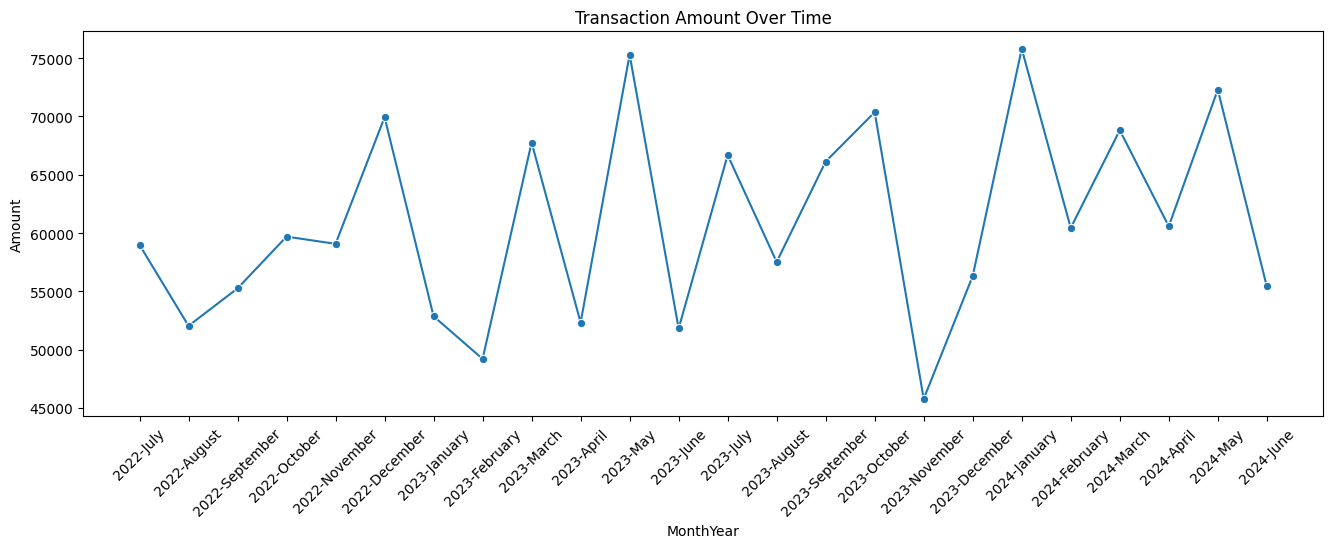

<ipython-input-32-fb3a3fa6280d>:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




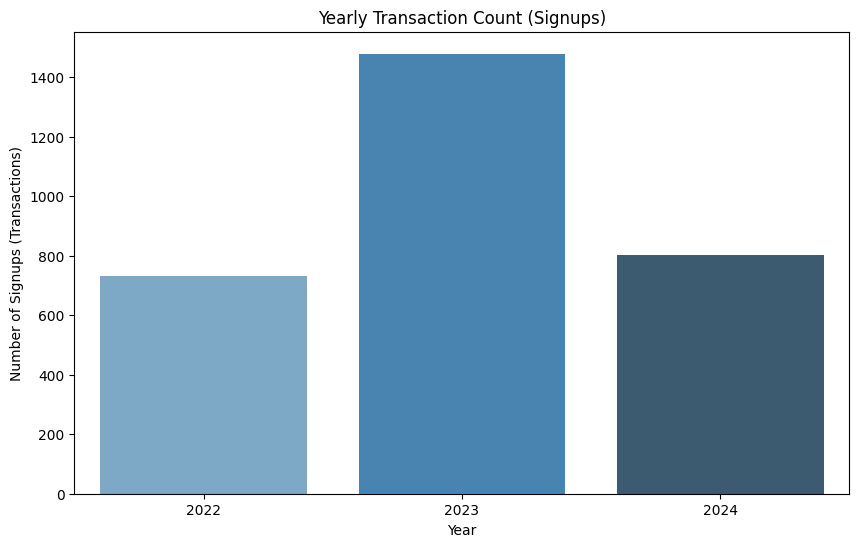

<ipython-input-32-fb3a3fa6280d>:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




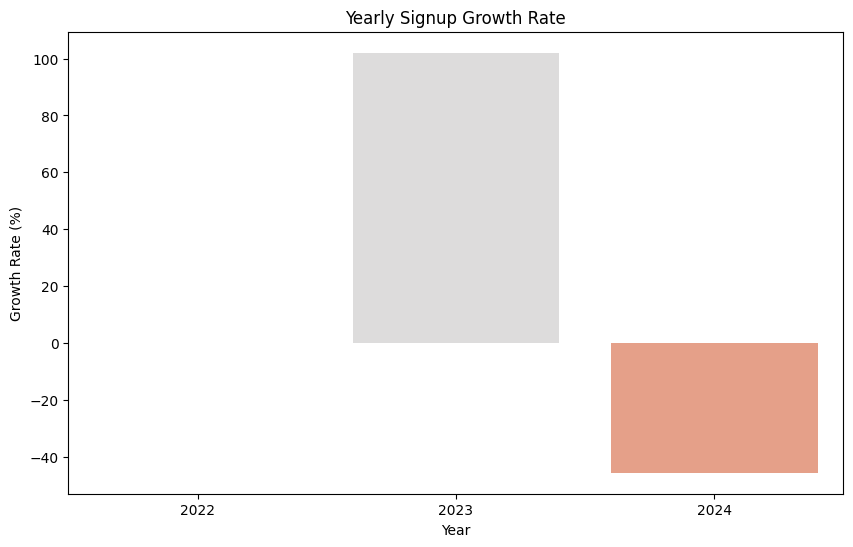

   Year  YearlySignups  GrowthRate
0  2022            732         NaN
1  2023           1479  102.049180
2  2024            804  -45.638945


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], format='mixed')

# Extract Year and Month from the 'TransactionDate'
customer_transactions['Year'] = customer_transactions['TransactionDate'].dt.year
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Create 'MonthYear' column for better grouping in the x-axis
customer_transactions['MonthYear'] = customer_transactions['Year'].astype(str) + '-' + customer_transactions['Month'].astype(str)

# Sort the data by 'TransactionDate' to maintain chronological order
customer_transactions.sort_values(by='TransactionDate', inplace=True)

# ----------------------------------
# Plot: Monthly Transaction Amounts
# ----------------------------------
# Set the figure size for the plot
plt.figure(figsize=(16, 5))

# Create a line plot of total transaction amount over time, grouped by 'MonthYear'
sns.lineplot(data=customer_transactions, x='MonthYear', y='Amount', estimator='sum', errorbar=None, marker="o")

# Set plot title and labels
plt.title('Transaction Amount Over Time')
plt.xticks(rotation=45)

# Show the plot
plt.show()

# ---------------------------------
# Calculate Yearly Signups (or transactions)
# ---------------------------------
# Group by 'Year' and count the number of transactions per year
yearly_signups = customer_transactions.groupby('Year').size().reset_index(name='YearlySignups')

# Plot yearly signups
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='YearlySignups', data=yearly_signups, palette='Blues_d')
plt.title('Yearly Transaction Count (Signups)')
plt.xlabel('Year')
plt.ylabel('Number of Signups (Transactions)')
plt.show()

# ---------------------------------
# Calculate Signup Growth Rate
# ---------------------------------
# Calculate year-over-year growth rate
yearly_signups['GrowthRate'] = yearly_signups['YearlySignups'].pct_change() * 100

# Plot signup growth rate
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='GrowthRate', data=yearly_signups, palette='coolwarm')
plt.title('Yearly Signup Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.show()

# Display the final Yearly Signups with Growth Rate
print(yearly_signups)


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], format='mixed')

# Extract Year and Month from the 'TransactionDate'
customer_transactions['Year'] = customer_transactions['TransactionDate'].dt.year
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Create 'MonthYear' column for better grouping in the x-axis
customer_transactions['MonthYear'] = customer_transactions['TransactionDate'].dt.to_period('M').astype(str)

# Aggregate the data to get total transaction amount per MonthYear
monthly_transactions = customer_transactions.groupby('MonthYear')['Amount'].sum().reset_index()

# Convert 'MonthYear' to actual datetime format for better x-axis handling
monthly_transactions['MonthYear'] = pd.to_datetime(monthly_transactions['MonthYear'])

# Identify the highest and lowest transaction months
max_transaction = monthly_transactions.loc[monthly_transactions['Amount'].idxmax()]
min_transaction = monthly_transactions.loc[monthly_transactions['Amount'].idxmin()]

# Calculate the average transaction amount
average_transaction_amount = monthly_transactions['Amount'].mean()

# Create a line plot of total transaction amount over time, grouped by 'MonthYear'
fig = px.line(
    monthly_transactions,
    x='MonthYear',
    y='Amount',
    title='Total Transaction Amount Over Time',
    labels={'Amount': 'Total Amount', 'MonthYear': 'Month-Year'},
    markers=True,  # Add markers for sharper points
    line_shape='linear'  # Use straight lines instead of smoothing
)

# Rotate x-axis labels for better readability and set interval
fig.update_xaxes(tickangle=45, dtick="M3", tickformat="%b %Y")

# Enhance hover info to show exact Month-Year and total amount
fig.update_traces(
    hovertemplate='<b>%{x|%B %Y}</b><br>Total Amount: %{y:,.2f}'
)

# Add an average line to the chart
fig.add_hline(
    y=average_transaction_amount,
    line_dash="dash",
    line_color="orange",
    annotation_text=f"Average: {average_transaction_amount:,.2f}",
    annotation_position="top right",
    opacity=0.6
)

# Add annotations for highest and lowest points with colored text and comma formatting
fig.add_annotation(
    x=max_transaction['MonthYear'],
    y=max_transaction['Amount'],
    text=f"Highest: {max_transaction['MonthYear'].strftime('%B %Y')} - {max_transaction['Amount']:,.2f}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(color="green", size=12),
    opacity=0.7
)

fig.add_annotation(
    x=min_transaction['MonthYear'],
    y=min_transaction['Amount'],
    text=f"Lowest: {min_transaction['MonthYear'].strftime('%B %Y')} - {min_transaction['Amount']:,.2f}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=40,
    font=dict(color="red", size=12),
    opacity=0.7
)

# Show the plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], format='mixed')

# Extract Year and Month from the 'TransactionDate'
customer_transactions['Year'] = customer_transactions['TransactionDate'].dt.year
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Create 'MonthYear' column for better grouping in the x-axis
customer_transactions['MonthYear'] = customer_transactions['TransactionDate'].dt.to_period('M').astype(str)

# Aggregate the data to get total count of transactions per MonthYear
monthly_transaction_count = customer_transactions['MonthYear'].value_counts().reset_index()
monthly_transaction_count.columns = ['MonthYear', 'TransactionCount']

# Convert 'MonthYear' to actual datetime format for better x-axis handling
monthly_transaction_count['MonthYear'] = pd.to_datetime(monthly_transaction_count['MonthYear'])

# Sort by 'MonthYear' to ensure correct chronological order
monthly_transaction_count.sort_values(by='MonthYear', inplace=True)

# Identify the highest and lowest transaction count months
max_transaction = monthly_transaction_count.loc[monthly_transaction_count['TransactionCount'].idxmax()]
min_transaction = monthly_transaction_count.loc[monthly_transaction_count['TransactionCount'].idxmin()]

# Create a line plot of total transaction count over time, grouped by 'MonthYear'
fig = px.line(
    monthly_transaction_count,
    x='MonthYear',
    y='TransactionCount',
    title='Total Transaction Count Over Time',
    labels={'TransactionCount': 'Total Count', 'MonthYear': 'Month-Year'},
    markers=True,
    line_shape='linear'  # Use straight lines instead of smooth curves
)

# Update line and marker color to match previous chart's color scheme
fig.update_traces(
    line=dict(color='#fa7e6b'),  # Muted red-pink for the line
    marker=dict(color='#fa7e6b', size=6),  # Same color for markers, no borders
    hovertemplate='<b>%{x|%B %Y}</b><br>Total Transactions: %{y:,}'
)

# Rotate x-axis labels for better readability and set interval
fig.update_xaxes(tickangle=45, dtick="M3", tickformat="%b %Y")

# Add annotations for highest and lowest points with updated colors
fig.add_annotation(
    x=max_transaction['MonthYear'],
    y=max_transaction['TransactionCount'],
    text=f"Highest: {max_transaction['MonthYear'].strftime('%B %Y')} - {max_transaction['TransactionCount']:,}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(color="#fa7e6b", size=12),  # Use muted red-pink for annotations
    opacity=0.7
)

fig.add_annotation(
    x=min_transaction['MonthYear'],
    y=min_transaction['TransactionCount'],
    text=f"Lowest: {min_transaction['MonthYear'].strftime('%B %Y')} - {min_transaction['TransactionCount']:,}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=40,
    font=dict(color="#fa7e6b", size=12),  # Use muted red-pink for annotations
    opacity=0.7
)

# Show the plot
fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], format='mixed')

# Extract Year and Month from the 'TransactionDate'
customer_transactions['Year'] = customer_transactions['TransactionDate'].dt.year
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Create 'MonthYear' column for better grouping in the x-axis
customer_transactions['MonthYear'] = customer_transactions['TransactionDate'].dt.to_period('M').astype(str)

# Aggregate the data to get total transaction amount and count per MonthYear
monthly_data = customer_transactions.groupby('MonthYear').agg(
    TotalAmount=('Amount', 'sum'),
    TransactionCount=('Amount', 'count')
).reset_index()

# Convert 'MonthYear' to actual datetime format for better x-axis handling
monthly_data['MonthYear'] = pd.to_datetime(monthly_data['MonthYear'])

# Sort by 'MonthYear' to ensure correct chronological order
monthly_data.sort_values(by='MonthYear', inplace=True)

# Create a figure with bar for total transaction amount and line for transaction count
fig = go.Figure()

# Add bar chart for total transaction amount
fig.add_trace(
    go.Bar(
        x=monthly_data['MonthYear'],
        y=monthly_data['TotalAmount'],
        name='Total Amount',
        marker=dict(color='#6489fa'),  # Softer blue for Total Amount
        yaxis='y1',
        hovertemplate='<b>%{x|%B %Y}</b><br>Total Amount: %{y:,.2f}'
    )
)

# Add line for total transaction count
fig.add_trace(
    go.Scatter(
        x=monthly_data['MonthYear'],
        y=monthly_data['TransactionCount'],
        name='Transaction Count',
        mode='lines+markers',
        line=dict(color='#fa7e6b', width=2),  # Muted red-pink line for Transaction Count
        marker=dict(size=6, color='#fa7e6b'),  # Borderless markers, matching the line color
        yaxis='y2',
        hovertemplate='<b>%{x|%B %Y}</b><br>Transaction Count: %{y:,}'
    )
)

# Set up the layout for dual-axis chart
fig.update_layout(
    title='Total Transaction Amount and Count Over Time',
    xaxis=dict(title='Month-Year', tickangle=45, tickformat="%b %Y"),
    yaxis=dict(
        title='Total Amount',
        titlefont=dict(color='#6489fa'),
        tickfont=dict(color='#6489fa'),
        side='left',
    ),
    yaxis2=dict(
        title='Transaction Count',
        titlefont=dict(color='#fa7e6b'),
        tickfont=dict(color='#fa7e6b'),
        overlaying='y',
        side='right'
    ),
    barmode='group',  # Ensure bars and line can be compared easily
    legend=dict(x=0.5, y=1.1, orientation='h')
)

# Show the combined plot
fig.show()


In [ ]:
import plotly.express as px

# Group by 'Year' and count the number of transactions per year
yearly_signups = customer_transactions.groupby('Year').size().reset_index(name='YearlySignups')

# Create a bar chart for yearly transaction counts
fig = px.bar(
    yearly_signups,
    x='Year',
    y='YearlySignups',
    title='Yearly Transaction Count (Signups)',
    labels={'YearlySignups': 'Number of Signups (Transactions)', 'Year': 'Year'},
    color='YearlySignups',
    color_continuous_scale='Blues'
)

# Show the plot
fig.show()


In [ ]:
import plotly.express as px

# Calculate year-over-year growth rate
yearly_signups['GrowthRate'] = yearly_signups['YearlySignups'].pct_change() * 100

# Create a bar chart for yearly signup growth rate
fig = px.bar(
    yearly_signups,
    x='Year',
    y='GrowthRate',
    title='Yearly Signup Growth Rate',
    labels={'GrowthRate': 'Growth Rate (%)', 'Year': 'Year'},
    color='GrowthRate',
    color_continuous_scale='RdBu'
)

# Show the plot
fig.show()

# Display the final Yearly Signups with Growth Rate
print(yearly_signups)


   Year  YearlySignups  GrowthRate
0  2022            732         NaN
1  2023           1479  102.049180
2  2024            804  -45.638945


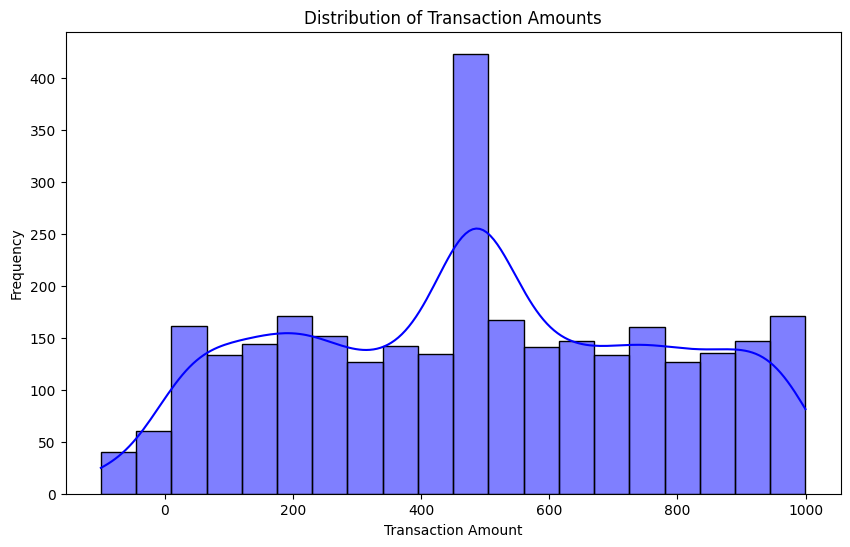

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_transactions['Amount'], bins=20, kde=True, color='blue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Aggregate data to count transactions per product category
transaction_counts = customer_transactions['ProductCategory'].value_counts().reset_index()
transaction_counts.columns = ['ProductCategory', 'TransactionCount']

# Define a custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a bar chart to show the number of transactions per product category
fig = px.bar(
    transaction_counts,
    x='ProductCategory',
    y='TransactionCount',
    title='Transaction Count by Product Category',
    labels={'ProductCategory': 'Product Category', 'TransactionCount': 'Number of Transactions'},
    color='ProductCategory',
    color_discrete_map=color_map  # Use the custom color map
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Set opacity to 1 for solid colors
fig.update_traces(opacity=1)

# Show the chart
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Aggregate data to get the total transaction amount per product category
total_by_category = customer_transactions.groupby('ProductCategory')['Amount'].sum().reset_index()

# Define a custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a bar chart to show the total transaction amount per product category
fig = px.bar(
    total_by_category,
    x='ProductCategory',
    y='Amount',
    title='Total Transaction Amount by Product Category',
    labels={'ProductCategory': 'Product Category', 'Amount': 'Total Transaction Amount'},
    color='ProductCategory',
    color_discrete_map=color_map  # Use the custom color map
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Set opacity to 1 for solid colors
fig.update_traces(opacity=1)

# Show the chart
fig.show()


In [4]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Aggregate data to get the total transaction amount per product category
total_by_category = customer_transactions.groupby('ProductCategory')['Amount'].sum().reset_index()

# Define a custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a pie chart to show the total transaction amount per product category
fig = px.pie(
    total_by_category,
    names='ProductCategory',
    values='Amount',
    title='Total Transaction Amount by Product Category',
    color='ProductCategory',
    color_discrete_map=color_map  # Use the custom color map
)

# Customize labels to display in the desired format and place them outside the pie chart
fig.update_traces(
    textposition='outside',
    texttemplate='%{label}<br>%{percent:.2%}<br>%{value:,.2f}',  # Format to show category, percentage, and amount
    hovertemplate='%{label}<br>Amount: %{value:,.2f}<br>Percent: %{percent}<extra></extra>',  # Customize hover info
)

# Show the chart
fig.show()


<ipython-input-36-aa2288e101af>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




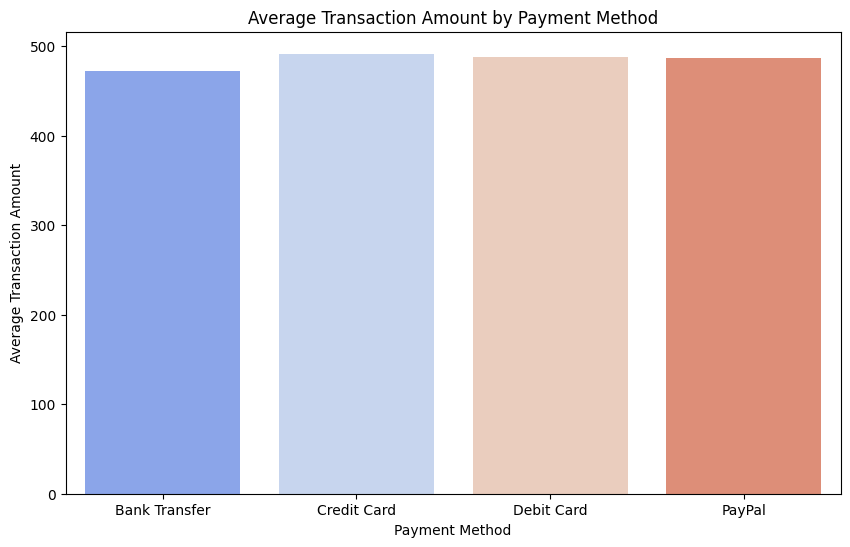

In [ ]:
plt.figure(figsize=(10, 6))
avg_by_payment = customer_transactions.groupby('PaymentMethod')['Amount'].mean().reset_index()
sns.barplot(x='PaymentMethod', y='Amount', data=avg_by_payment, palette='coolwarm')
plt.title('Average Transaction Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Transaction Amount')
plt.show()


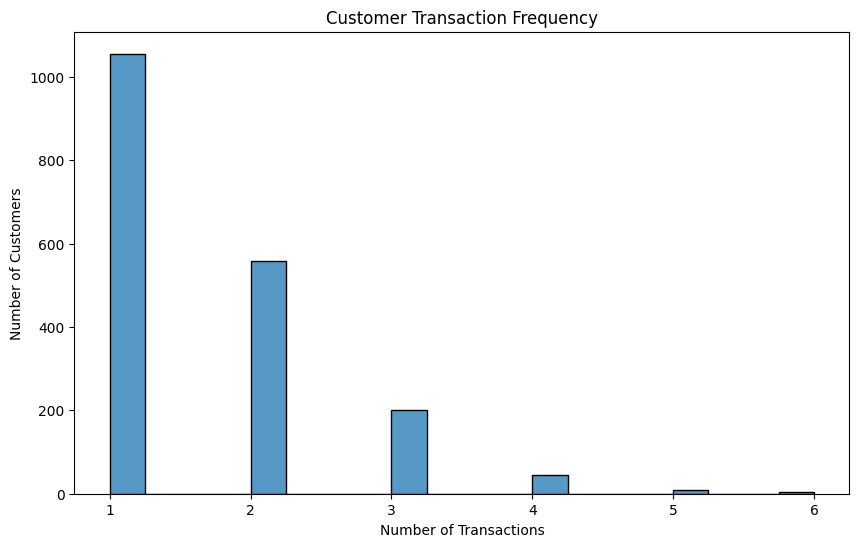

In [ ]:
plt.figure(figsize=(10, 6))
transaction_freq = customer_transactions['CustomerID'].value_counts().reset_index()
transaction_freq.columns = ['CustomerID', 'TransactionCount']

sns.histplot(transaction_freq['TransactionCount'], bins=20, kde=False)
plt.title('Customer Transaction Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()


<ipython-input-38-3dfb87ea967f>:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




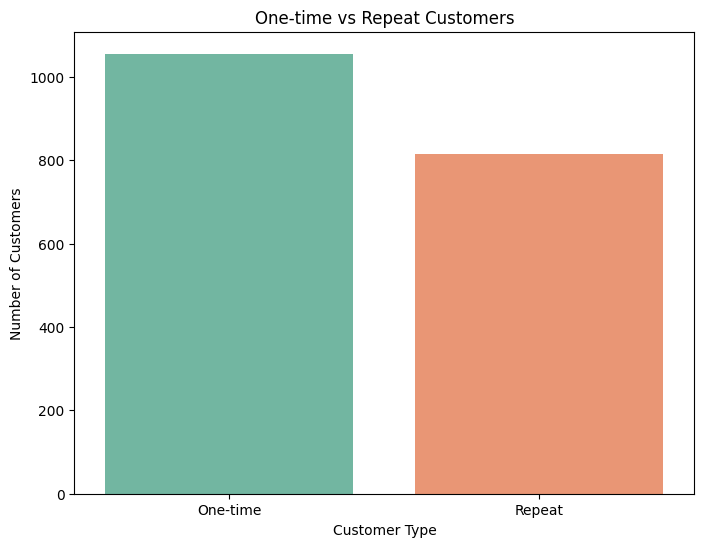

One-time customers: 1056
Repeat customers: 815


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Classify customers as 'One-time' or 'Repeat'
customer_transaction_status = customer_transaction_counts.apply(lambda x: 'Repeat' if x > 1 else 'One-time')

# Count how many customers are 'One-time' and how many are 'Repeat'
customer_status_counts = customer_transaction_status.value_counts()

# Plot the bar chart to show the number of One-time vs Repeat customers
plt.figure(figsize=(8, 6))
sns.barplot(x=customer_status_counts.index, y=customer_status_counts.values, palette='Set2')
plt.title('One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.show()

# Print out the exact numbers for one-time and repeat customers
print(f"One-time customers: {customer_status_counts['One-time']}")
print(f"Repeat customers: {customer_status_counts['Repeat']}")


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Classify customers as 'One-time' or 'Repeat'
customer_transaction_status = customer_transaction_counts.apply(lambda x: 'Repeat' if x > 1 else 'One-time')

# Count how many customers are 'One-time' and how many are 'Repeat'
customer_status_counts = customer_transaction_status.value_counts().reset_index(name='CustomerCount')
customer_status_counts.columns = ['CustomerType', 'CustomerCount']

# Create a bar chart using Plotly
fig = px.bar(
    customer_status_counts,
    x='CustomerType',
    y='CustomerCount',
    title='One-time vs Repeat Customers',
    labels={'CustomerType': 'Customer Type', 'CustomerCount': 'Number of Customers'},
    color='CustomerType',
    color_discrete_map={'One-time': '#88B04B', 'Repeat': '#FF6F61'}  # Custom colors
)

# Customize hover info and color
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Number of Customers: %{y}',
    opacity=0.9
)

# Show the chart
fig.show()

# Print out the exact numbers for one-time and repeat customers
one_time_customers = customer_status_counts[customer_status_counts['CustomerType'] == 'One-time']['CustomerCount'].values[0]
repeat_customers = customer_status_counts[customer_status_counts['CustomerType'] == 'Repeat']['CustomerCount'].values[0]
print(f"One-time customers: {one_time_customers}")
print(f"Repeat customers: {repeat_customers}")


One-time customers: 1056
Repeat customers: 815


In [1]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify repeat customers (those with more than 1 transaction)
repeat_customers = customer_transaction_counts[customer_transaction_counts > 1].index

# Filter the transactions to only include those from repeat customers
repeat_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(repeat_customers)]

# Count the products or product categories bought by repeat customers
repeat_purchase_by_category = repeat_customer_transactions['ProductCategory'].value_counts().reset_index()
repeat_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Define a consistent custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a bar chart using Plotly with the same color scheme
fig = px.bar(
    repeat_purchase_by_category,
    x='ProductCategory',
    y='PurchaseCount',
    title='Most Frequent Product Categories Purchased by Repeat Customers',
    labels={'ProductCategory': 'Product Category', 'PurchaseCount': 'Number of Purchases'},
    color='ProductCategory',
    color_discrete_map=color_map  # Ensure the same color map is used
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Set opacity to 1 for solid colors
fig.update_traces(opacity=1)

# Show the chart
fig.show()

# Display top 5 product categories bought by repeat customers
print("Top 5 product categories bought by repeat customers:")
print(repeat_purchase_by_category.head(5))


Top 5 product categories bought by repeat customers:
   ProductCategory  PurchaseCount
0         Clothing            387
1      Electronics            367
2  Health & Beauty            345
3       Automotive            338
4    Home & Garden            336


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify one-time customers (those with only 1 transaction)
one_time_customers = customer_transaction_counts[customer_transaction_counts == 1].index

# Filter the transactions to only include those from one-time customers
one_time_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(one_time_customers)]

# Count the products or product categories bought by one-time customers
one_time_purchase_by_category = one_time_customer_transactions['ProductCategory'].value_counts().reset_index()
one_time_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Define a custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a bar chart using Plotly
fig = px.bar(
    one_time_purchase_by_category,
    x='ProductCategory',
    y='PurchaseCount',
    title='Most Frequent Product Categories Purchased by One-time Customers',
    labels={'ProductCategory': 'Product Category', 'PurchaseCount': 'Number of Purchases'},
    color='ProductCategory',
    color_discrete_map=color_map  # Use the custom color map
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Set opacity to 1 for solid colors
fig.update_traces(opacity=1)

# Show the chart
fig.show()

# Display top 5 product categories bought by one-time customers
print("Top 5 product categories bought by one-time customers:")
print(one_time_purchase_by_category.head(5))


Top 5 product categories bought by one-time customers:
   ProductCategory  PurchaseCount
0       Automotive            202
1      Electronics            197
2    Home & Garden            194
3         Clothing            184
4  Health & Beauty            183


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify customers with more than 4 transactions
high_transaction_customers = customer_transaction_counts[customer_transaction_counts > 4].index

# Filter the transactions to only include those from customers with more than 4 transactions
high_transaction_customer_transactions = customer_transactions[customer_transactions['CustomerID'].isin(high_transaction_customers)]

# Count the products or product categories bought by customers with more than 4 transactions
high_transaction_purchase_by_category = high_transaction_customer_transactions['ProductCategory'].value_counts().reset_index()
high_transaction_purchase_by_category.columns = ['ProductCategory', 'PurchaseCount']

# Define a custom color map for product categories
color_map = {
    'Clothing': '#FF6F61',        # Coral
    'Electronics': '#6B5B95',     # Purple
    'Automotive': '#88B04B',      # Green
    'Home & Garden': '#FFA07A',   # Light Coral
    'Health & Beauty': '#F7CAC9', # Pink
    'Uncategorized': '#92A8D1',   # Light Blue
}

# Create a bar chart using Plotly
fig = px.bar(
    high_transaction_purchase_by_category,
    x='ProductCategory',
    y='PurchaseCount',
    title='Most Frequent Product Categories Purchased by Customers with More Than 4 Transactions',
    labels={'ProductCategory': 'Product Category', 'PurchaseCount': 'Number of Purchases'},
    color='ProductCategory',
    color_discrete_map=color_map  # Use the custom color map
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Set opacity to 1 for solid colors
fig.update_traces(opacity=1)

# Show the chart
fig.show()

# Display top 5 product categories bought by customers with more than 4 transactions
print("Top 5 product categories bought by customers with more than 4 transactions:")
print(high_transaction_purchase_by_category.head(5))


Top 5 product categories bought by customers with more than 4 transactions:
   ProductCategory  PurchaseCount
0         Clothing             15
1      Electronics             14
2       Automotive             13
3    Home & Garden             10
4  Health & Beauty              9


In [4]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Count the number of transactions per customer
customer_transaction_counts = customer_transactions['CustomerID'].value_counts()

# Identify customers based on transaction frequency
one_time_customers = customer_transaction_counts[customer_transaction_counts == 1].index
two_time_customers = customer_transaction_counts[customer_transaction_counts == 2].index
three_or_more_customers = customer_transaction_counts[customer_transaction_counts >= 3].index

# Filter the transactions based on the customer groups
one_time_transactions = customer_transactions[customer_transactions['CustomerID'].isin(one_time_customers)]
two_time_transactions = customer_transactions[customer_transactions['CustomerID'].isin(two_time_customers)]
three_or_more_transactions = customer_transactions[customer_transactions['CustomerID'].isin(three_or_more_customers)]

# Count product categories for each group
one_time_purchase_by_category = one_time_transactions['ProductCategory'].value_counts().reset_index()
one_time_purchase_by_category.columns = ['ProductCategory', 'One Time Purchase']

two_time_purchase_by_category = two_time_transactions['ProductCategory'].value_counts().reset_index()
two_time_purchase_by_category.columns = ['ProductCategory', 'Two Time Purchase']

three_or_more_purchase_by_category = three_or_more_transactions['ProductCategory'].value_counts().reset_index()
three_or_more_purchase_by_category.columns = ['ProductCategory', 'Three Or More Purchase']

# Merge all three datasets for comparison
comparison_df = pd.merge(one_time_purchase_by_category, two_time_purchase_by_category, on='ProductCategory', how='outer')
comparison_df = pd.merge(comparison_df, three_or_more_purchase_by_category, on='ProductCategory', how='outer').fillna(0)

# Melt the dataframe for a grouped bar chart
comparison_melted = comparison_df.melt(
    id_vars='ProductCategory',
    value_vars=['One Time Purchase', 'Two Time Purchase', 'Three Or More Purchase'],
    var_name='CustomerType', value_name='PurchaseCount'
)

# Define a consistent custom color map for the customer groups (optional)
color_scheme = {
    'One Time Purchase': '#636EFA',   # Blue
    'Two Time Purchase': '#EF553B',   # Red
    'Three Or More Purchase': '#00CC96'  # Green
}

# Create a grouped bar chart
fig = px.bar(
    comparison_melted,
    x='ProductCategory',
    y='PurchaseCount',
    color='CustomerType',
    barmode='group',
    title='Comparison of Product Categories Purchased by One-time, Two-time, and Three or More Customers',
    labels={'ProductCategory': 'Product Category', 'PurchaseCount': 'Number of Purchases'},
    color_discrete_map=color_scheme  # Customize colors for clarity
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Show the chart
fig.show()

# Display the top 5 product categories bought by each group
print("Top 5 product categories bought by one-time customers:")
print(one_time_purchase_by_category.head(5))

print("\nTop 5 product categories bought by two-time customers:")
print(two_time_purchase_by_category.head(5))

print("\nTop 5 product categories bought by customers with three or more transactions:")
print(three_or_more_purchase_by_category.head(5))


Top 5 product categories bought by one-time customers:
   ProductCategory  One Time Purchase
0       Automotive                202
1      Electronics                197
2    Home & Garden                194
3         Clothing                184
4  Health & Beauty                183

Top 5 product categories bought by two-time customers:
   ProductCategory  Two Time Purchase
0         Clothing                220
1       Automotive                202
2  Health & Beauty                199
3      Electronics                197
4    Home & Garden                182

Top 5 product categories bought by customers with three or more transactions:
   ProductCategory  Three Or More Purchase
0      Electronics                     170
1         Clothing                     167
2    Home & Garden                     154
3  Health & Beauty                     146
4       Automotive                     136


<ipython-input-42-f59d582fac39>:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




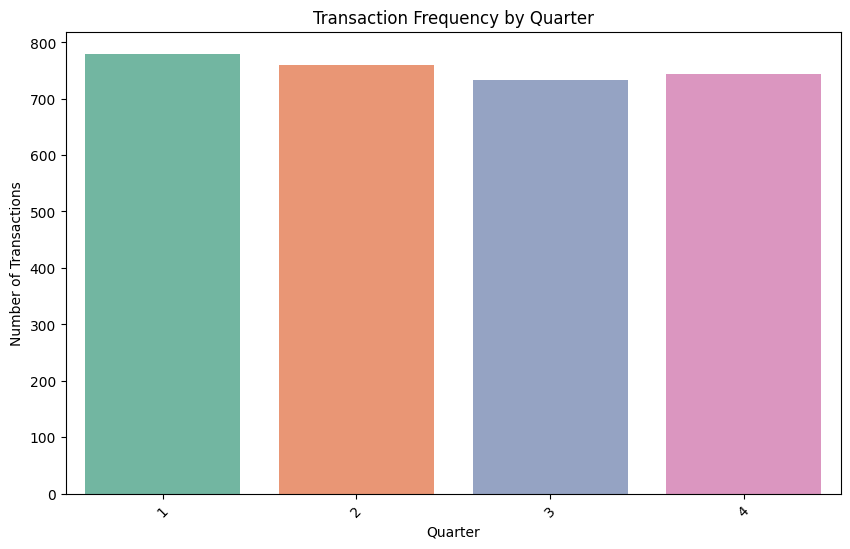

The quarter with the most transactions is Q1 with 780 transactions.


<ipython-input-42-f59d582fac39>:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




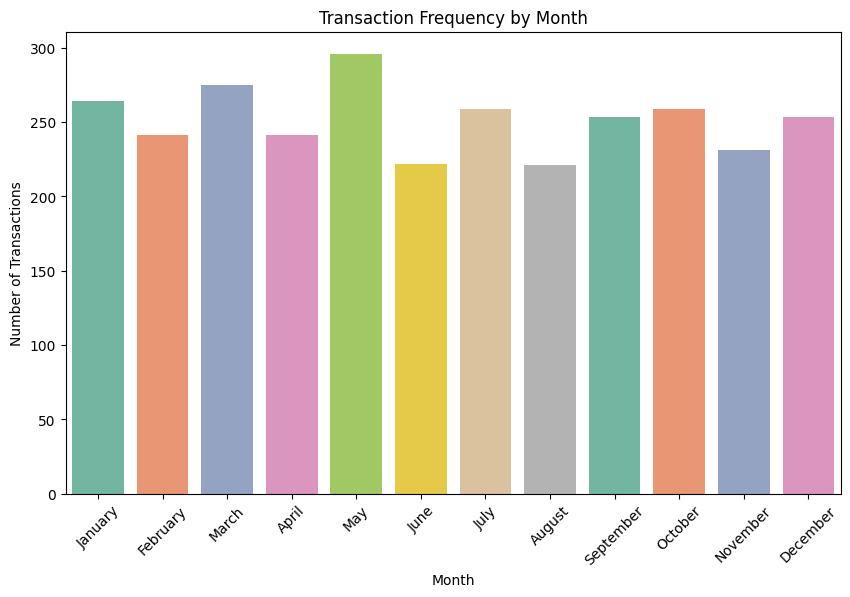

The month with the most transactions is May with 296 transactions.

Transaction counts per quarter:
   Quarter  TransactionCount
0        1               780
1        2               759
3        3               733
2        4               743

Transaction counts per month:
        Month  TransactionCount
2     January               264
8    February               241
1       March               275
7       April               241
0         May               296
10       June               222
3        July               259
11     August               221
5   September               253
4     October               259
9    November               231
6    December               253


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Extract the quarter (just Q1, Q2, Q3, Q4) from 'TransactionDate'
customer_transactions['Quarter'] = customer_transactions['TransactionDate'].dt.quarter

# ---------------------------
# Frequency of Transactions per Quarter (Q1, Q2, Q3, Q4)
# ---------------------------
# Count the number of transactions per quarter
transaction_per_quarter = customer_transactions['Quarter'].value_counts().reset_index()
transaction_per_quarter.columns = ['Quarter', 'TransactionCount']

# Sort the quarters in order (Q1 to Q4)
transaction_per_quarter = transaction_per_quarter.sort_values('Quarter')

# Identify the quarter with the most transactions
most_transacted_quarter = transaction_per_quarter.loc[transaction_per_quarter['TransactionCount'].idxmax()]

# Plot the frequency of transactions per quarter
plt.figure(figsize=(10, 6))
sns.barplot(x='Quarter', y='TransactionCount', data=transaction_per_quarter, palette='Set2')
plt.title('Transaction Frequency by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# Display the quarter with the most transactions
print(f"The quarter with the most transactions is Q{most_transacted_quarter['Quarter']} with {most_transacted_quarter['TransactionCount']} transactions.")

# ---------------------------
# Frequency of Transactions per Month
# ---------------------------
# Extract month names
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Count the number of transactions per month
transaction_per_month = customer_transactions['Month'].value_counts().reset_index()
transaction_per_month.columns = ['Month', 'TransactionCount']

# Ensure the months are in the correct calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transaction_per_month['Month'] = pd.Categorical(transaction_per_month['Month'], categories=month_order, ordered=True)
transaction_per_month = transaction_per_month.sort_values('Month')

# Identify the month with the most transactions
most_transacted_month = transaction_per_month.loc[transaction_per_month['TransactionCount'].idxmax()]

# Plot the frequency of transactions per month
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='TransactionCount', data=transaction_per_month, palette='Set2')
plt.title('Transaction Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# Display the month with the most transactions
print(f"The month with the most transactions is {most_transacted_month['Month']} with {most_transacted_month['TransactionCount']} transactions.")

# Output the transaction counts per quarter and per month
print("\nTransaction counts per quarter:")
print(transaction_per_quarter)

print("\nTransaction counts per month:")
print(transaction_per_month)


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Extract the quarter (just Q1, Q2, Q3, Q4) from 'TransactionDate'
customer_transactions['Quarter'] = customer_transactions['TransactionDate'].dt.quarter

# Count the number of transactions per quarter
transaction_per_quarter = customer_transactions['Quarter'].value_counts().reset_index()
transaction_per_quarter.columns = ['Quarter', 'TransactionCount']

# Sort the quarters in order (Q1 to Q4)
transaction_per_quarter = transaction_per_quarter.sort_values('Quarter')

# Identify the quarter with the most transactions
most_transacted_quarter = transaction_per_quarter.loc[transaction_per_quarter['TransactionCount'].idxmax()]

# Create a bar chart for transactions by quarter using Plotly
fig_quarter = px.bar(
    transaction_per_quarter,
    x='Quarter',
    y='TransactionCount',
    title='Transaction Frequency by Quarter',
    labels={'Quarter': 'Quarter', 'TransactionCount': 'Number of Transactions'},
    color='Quarter',
    color_discrete_sequence=px.colors.qualitative.Set2  # Use Set2 color palette
)

# Show the chart
fig_quarter.show()

# Display the quarter with the most transactions
print(f"The quarter with the most transactions is Q{most_transacted_quarter['Quarter']} with {most_transacted_quarter['TransactionCount']} transactions.")

# Output the transaction counts per quarter
print("\nTransaction counts per quarter:")
print(transaction_per_quarter)


The quarter with the most transactions is Q1 with 780 transactions.

Transaction counts per quarter:
   Quarter  TransactionCount
0        1               780
1        2               759
3        3               733
2        4               743


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Extract month names
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Count the number of transactions per month
transaction_per_month = customer_transactions['Month'].value_counts().reset_index()
transaction_per_month.columns = ['Month', 'TransactionCount']

# Ensure the months are in the correct calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transaction_per_month['Month'] = pd.Categorical(transaction_per_month['Month'], categories=month_order, ordered=True)
transaction_per_month = transaction_per_month.sort_values('Month')

# Identify the month with the most transactions
most_transacted_month = transaction_per_month.loc[transaction_per_month['TransactionCount'].idxmax()]

# Create a bar chart for transactions by month using Plotly
fig_month = px.bar(
    transaction_per_month,
    x='Month',
    y='TransactionCount',
    title='Transaction Frequency by Month',
    labels={'Month': 'Month', 'TransactionCount': 'Number of Transactions'},
    color='Month',
    color_discrete_sequence=px.colors.qualitative.Set2  # Use Set2 color palette
)

# Rotate x-axis labels for better readability
fig_month.update_xaxes(tickangle=45)

# Show the chart
fig_month.show()

# Display the month with the most transactions
print(f"The month with the most transactions is {most_transacted_month['Month']} with {most_transacted_month['TransactionCount']} transactions.")

# Output the transaction counts per month
print("\nTransaction counts per month:")
print(transaction_per_month)


The month with the most transactions is May with 296 transactions.

Transaction counts per month:
        Month  TransactionCount
2     January               264
8    February               241
1       March               275
7       April               241
0         May               296
10       June               222
3        July               259
11     August               221
5   September               253
4     October               259
9    November               231
6    December               253


In [ ]:
import pandas as pd
import plotly.express as px

# Load customer transactions dataset
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')

# Convert 'TransactionDate' to datetime format
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Extract month names
customer_transactions['Month'] = customer_transactions['TransactionDate'].dt.month_name()

# Count the number of transactions per month
transaction_per_month = customer_transactions['Month'].value_counts().reset_index()
transaction_per_month.columns = ['Month', 'TransactionCount']

# Identify the month with the most transactions
most_transacted_month = transaction_per_month.loc[transaction_per_month['TransactionCount'].idxmax()]

# Sort the data by TransactionCount in descending order
transaction_per_month = transaction_per_month.sort_values(by='TransactionCount', ascending=False)

# Create a color list to highlight the month with the most transactions
colors = ['#FF6F61' if month == most_transacted_month['Month'] else '#CCCCCC' for month in transaction_per_month['Month']]

# Create a bar chart for transactions by month using Plotly
fig_month = px.bar(
    transaction_per_month,
    x='Month',
    y='TransactionCount',
    title='Transaction Frequency by Month (Descending Order)',
    labels={'Month': 'Month', 'TransactionCount': 'Number of Transactions'},
)

# Apply custom colors to highlight the most transacted month
fig_month.update_traces(marker_color=colors)

# Rotate x-axis labels for better readability
fig_month.update_xaxes(tickangle=45)

# Show the chart
fig_month.show()

# Display the month with the most transactions
print(f"The month with the most transactions is {most_transacted_month['Month']} with {most_transacted_month['TransactionCount']} transactions.")


The month with the most transactions is May with 296 transactions.


## **Social Media Interaction**

In [ ]:
# Check if CustomerID from social media interactions exists in customer demographics
socmed_interactions['ExistsInDemographics'] = socmed_interactions['CustomerID'].isin(customer_demographics['CustomerID']).apply(lambda x: 'Yes' if x else 'No')

# Print the results to see if customers are present or not
print(socmed_interactions[['CustomerID', 'ExistsInDemographics']])


                                CustomerID ExistsInDemographics
0     2dcb9523-356b-40b2-a67b-1f27797de261                  Yes
1     e12c37b3-7d4d-472f-9fd8-0df2cb3001aa                  Yes
2     08a911a3-65e6-4f5d-a6a1-ae7ddcbe28a2                  Yes
3     efdfdfc9-5dbb-4478-911a-101a390a0285                  Yes
4     ca1e90f6-0e5f-492e-ab92-252ff540da18                  Yes
...                                    ...                  ...
3015  e06f0e16-8e48-483b-b103-9f105b139ca8                  Yes
3016  4d20c2b1-2f8a-4066-902c-bd068c2adccc                  Yes
3017  b7b84b81-c61b-4f23-b3db-b18010484122                  Yes
3018  5659a8c6-0397-4396-b561-52ec1c8a760b                   No
3019  5711d1af-71f2-4b99-a965-3ffdc39d32c8                   No

[3020 rows x 2 columns]


In [ ]:
import pandas as pd

# Load datasets
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Ensure all CustomerID columns are of the same data type
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)

# 1. Identify customers who interacted on social media
interacted_customers = socmed_interactions['CustomerID'].unique()

# 2. Identify customers who made purchases
purchasing_customers = customer_transactions['CustomerID'].unique()

# 3. Find customers who interacted and also made a purchase (intersection of both sets)
interacted_and_purchased = set(interacted_customers).intersection(set(purchasing_customers))

# 4. Calculate conversion rate
total_interacted = len(interacted_customers)
total_converted = len(interacted_and_purchased)

conversion_rate = (total_converted / total_interacted) * 100

# Output the conversion rate
print(f"Total Customers Who Interacted: {total_interacted}")
print(f"Total Customers Who Interacted and Purchased: {total_converted}")
print(f"Conversion Rate from Social Media Interactions to Purchases: {conversion_rate:.2f}%")


Total Customers Who Interacted: 1893
Total Customers Who Interacted and Purchased: 1181
Conversion Rate from Social Media Interactions to Purchases: 62.39%


In [ ]:
import pandas as pd

# Load datasets (replace with actual file paths or data)
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')


# Ensure CustomerID is of the same type across all datasets
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)
customer_demographics['CustomerID'] = customer_demographics['CustomerID'].astype(str)

# Step 1: Perform a LEFT JOIN between social media interactions and customer transactions
left_joined_data = pd.merge(socmed_interactions, customer_transactions, on='CustomerID', how='left')

# Step 2: Perform another LEFT JOIN between the result and customer demographics
final_merged_data = pd.merge(left_joined_data, customer_demographics, on='CustomerID', how='left')

# Step 3: Filter for customers present in all datasets (i.e., with non-null TransactionID and non-null CustomerID)
present_in_all = final_merged_data[final_merged_data['TransactionID'].notnull() & final_merged_data['CustomerID'].notnull()]

# Step 4: Count unique CustomerIDs who interacted on social media
total_unique_interacted_customers = socmed_interactions['CustomerID'].nunique()

# Step 5: Count unique CustomerIDs who are present in all datasets (those who made purchases)
unique_customers_in_all_datasets = present_in_all['CustomerID'].nunique()

# Step 6: Calculate conversion rate based on unique CustomerIDs
conversion_rate = (unique_customers_in_all_datasets / total_unique_interacted_customers) * 100

# Output the results
print(f"Total Unique Customers Who Interacted: {total_unique_interacted_customers}")
print(f"Total Unique Customers Present in All Datasets (Interacted and Bought): {unique_customers_in_all_datasets}")
print(f"Conversion Rate from Social Media Interactions to Purchases (Unique Customers): {conversion_rate:.2f}%")


Total Unique Customers Who Interacted: 1893
Total Unique Customers Present in All Datasets (Interacted and Bought): 1181
Conversion Rate from Social Media Interactions to Purchases (Unique Customers): 62.39%


In [ ]:
import pandas as pd

# Load datasets (replace with actual file paths or data)
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Ensure CustomerID is of the same type across all datasets
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype(str)
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype(str)
customer_demographics['CustomerID'] = customer_demographics['CustomerID'].astype(str)

# Step 1: Perform a LEFT JOIN between social media interactions and customer transactions
left_joined_data = pd.merge(socmed_interactions, customer_transactions, on='CustomerID', how='left')

# Step 2: Perform a RIGHT JOIN between the left_joined_data and customer demographics
final_merged_data = pd.merge(left_joined_data, customer_demographics, on='CustomerID', how='right')

# Step 3: Filter for customers present in all datasets (i.e., with non-null TransactionID and non-null CustomerID)
present_in_all = final_merged_data[final_merged_data['TransactionID'].notnull() & final_merged_data['CustomerID'].notnull()]

# Step 4: Count unique CustomerIDs who interacted on social media
total_unique_interacted_customers = socmed_interactions['CustomerID'].nunique()

# Step 5: Count unique CustomerIDs who are present in all datasets (those who made purchases)
unique_customers_in_all_datasets = present_in_all['CustomerID'].nunique()

# Step 6: Calculate conversion rate based on unique CustomerIDs
conversion_rate = (unique_customers_in_all_datasets / total_unique_interacted_customers) * 100

# Output the results
print(f"Total Unique Customers Who Interacted: {total_unique_interacted_customers}")
print(f"Total Unique Customers Present in All Datasets (Interacted and Bought): {unique_customers_in_all_datasets}")
print(f"Conversion Rate from Social Media Interactions to Purchases (Unique Customers): {conversion_rate:.2f}%")


Total Unique Customers Who Interacted: 1893
Total Unique Customers Present in All Datasets (Interacted and Bought): 1048
Conversion Rate from Social Media Interactions to Purchases (Unique Customers): 55.36%


In [ ]:
import pandas as pd
import plotly.express as px

socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Create a count of the platforms
platform_counts = socmed_interactions['Platform'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'Count']

# Create a Plotly bar chart
fig_platform = px.bar(
    platform_counts,
    x='Platform',
    y='Count',
    title='Social Media Interactions - Platform Distribution',
    labels={'Platform': 'Platform', 'Count': 'Number of Interactions'},
    color='Platform',
    color_discrete_sequence=px.colors.qualitative.Vivid
)

# Add values on top of the bars
fig_platform.update_traces(texttemplate='%{y}', textposition='outside')

# Show the chart
fig_platform.show()


In [ ]:
# Create a count of the interaction types
interaction_type_counts = socmed_interactions['InteractionType'].value_counts().reset_index()
interaction_type_counts.columns = ['InteractionType', 'Count']

# Create a Plotly bar chart
fig_interaction_type = px.bar(
    interaction_type_counts,
    x='InteractionType',
    y='Count',
    title='Social Media Interactions - Interaction Type Distribution',
    labels={'InteractionType': 'Interaction Type', 'Count': 'Number of Interactions'},
    color='InteractionType',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Add values on top of the bars
fig_interaction_type.update_traces(texttemplate='%{y}', textposition='outside')

# Show the chart
fig_interaction_type.show()


In [ ]:
# Create a count of the sentiments
sentiment_counts = socmed_interactions['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create a Plotly bar chart
fig_sentiment = px.bar(
    sentiment_counts,
    x='Sentiment',
    y='Count',
    title='Social Media Interactions - Sentiment Distribution',
    labels={'Sentiment': 'Sentiment', 'Count': 'Number of Interactions'},
    color='Sentiment',
    color_discrete_map={
        'Positive': '#2ECC71',  # Green for Positive
        'Neutral': '#F1C40F',   # Yellow for Neutral
        'Negative': '#E74C3C'   # Red for Negative
    }
)

# Add values on top of the bars
fig_sentiment.update_traces(texttemplate='%{y}', textposition='outside')

# Show the chart
fig_sentiment.show()


In [ ]:
# Count the sentiment distribution by interaction type
sentiment_by_interaction = socmed_interactions.groupby(['InteractionType', 'Sentiment']).size().reset_index(name='Count')

# Create a stacked bar chart using Plotly
fig_sentiment_interaction = px.bar(
    sentiment_by_interaction,
    x='InteractionType',
    y='Count',
    color='Sentiment',
    title='Sentiment Distribution by Interaction Type',
    labels={'InteractionType': 'Interaction Type', 'Count': 'Number of Interactions', 'Sentiment': 'Sentiment'},
    color_discrete_map={
        'Positive': '#2ECC71',  # Green
        'Neutral': '#F1C40F',   # Yellow
        'Negative': '#E74C3C'   # Red
    },
    barmode='stack'  # Stacked bars
)

# Show the chart
fig_sentiment_interaction.show()


In [ ]:
# Convert 'InteractionDate' to datetime format and extract the month-year
socmed_interactions['InteractionDate'] = pd.to_datetime(socmed_interactions['InteractionDate'])
socmed_interactions['MonthYear'] = socmed_interactions['InteractionDate'].dt.to_period('M').astype(str)

# Count the number of interactions per platform over time
platform_over_time = socmed_interactions.groupby(['MonthYear', 'Platform']).size().reset_index(name='Count')

# Create a line chart using Plotly
fig_platform_time = px.line(
    platform_over_time,
    x='MonthYear',
    y='Count',
    color='Platform',
    title='Platform Usage Over Time',
    labels={'MonthYear': 'Month-Year', 'Count': 'Number of Interactions', 'Platform': 'Platform'},
    markers=True
)

# Rotate x-axis labels for better readability
fig_platform_time.update_xaxes(tickangle=45)

# Show the chart
fig_platform_time.show()


In [ ]:
# Extract day of week and hour from the interaction date
socmed_interactions['DayOfWeek'] = socmed_interactions['InteractionDate'].dt.day_name()
socmed_interactions['Hour'] = socmed_interactions['InteractionDate'].dt.hour

# Create a pivot table to count interactions by day of the week and hour
heatmap_data = socmed_interactions.pivot_table(index='DayOfWeek', columns='Hour', values='InteractionID', aggfunc='count').fillna(0)

# Reorder the days of the week for the heatmap
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

# Create the heatmap using Plotly
import plotly.graph_objects as go

fig_heatmap = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    colorscale='Viridis',
    colorbar=dict(title='Number of Interactions')
))

fig_heatmap.update_layout(
    title='Heatmap of Interactions by Day of Week and Time of Day',
    xaxis=dict(title='Hour of Day'),
    yaxis=dict(title='Day of Week')
)

# Show the heatmap
fig_heatmap.show()


In [ ]:
# Count the sentiment trend over time (month-year)
sentiment_over_time = socmed_interactions.groupby(['MonthYear', 'Sentiment']).size().reset_index(name='Count')

# Create an area chart using Plotly
fig_sentiment_trend = px.area(
    sentiment_over_time,
    x='MonthYear',
    y='Count',
    color='Sentiment',
    title='Sentiment Trend Over Time',
    labels={'MonthYear': 'Month-Year', 'Count': 'Number of Interactions', 'Sentiment': 'Sentiment'},
    color_discrete_map={
        'Positive': '#2ECC71',
        'Neutral': '#F1C40F',
        'Negative': '#E74C3C'
    }
)

# Rotate x-axis labels for better readability
fig_sentiment_trend.update_xaxes(tickangle=45)

# Show the area chart
fig_sentiment_trend.show()


In [ ]:
# Count the number of interactions per platform for each sentiment
sentiment_by_platform = socmed_interactions.groupby(['Platform', 'Sentiment']).size().reset_index(name='Count')

# Create a grouped bar chart using Plotly
fig_sentiment_platform = px.bar(
    sentiment_by_platform,
    x='Platform',
    y='Count',
    color='Sentiment',
    barmode='group',
    title='Top Platforms for Each Sentiment',
    labels={'Platform': 'Platform', 'Count': 'Number of Interactions', 'Sentiment': 'Sentiment'},
    color_discrete_map={
        'Positive': '#2ECC71',
        'Neutral': '#F1C40F',
        'Negative': '#E74C3C'
    }
)

# Show the chart
fig_sentiment_platform.show()


## **Checking for correlation of data sets**

                  Age    Gender  IncomeLevel    Amount
Age          1.000000  0.042094     0.007696  0.040364
Gender       0.042094  1.000000    -0.022832 -0.031233
IncomeLevel  0.007696 -0.022832     1.000000 -0.017222
Amount       0.040364 -0.031233    -0.017222  1.000000


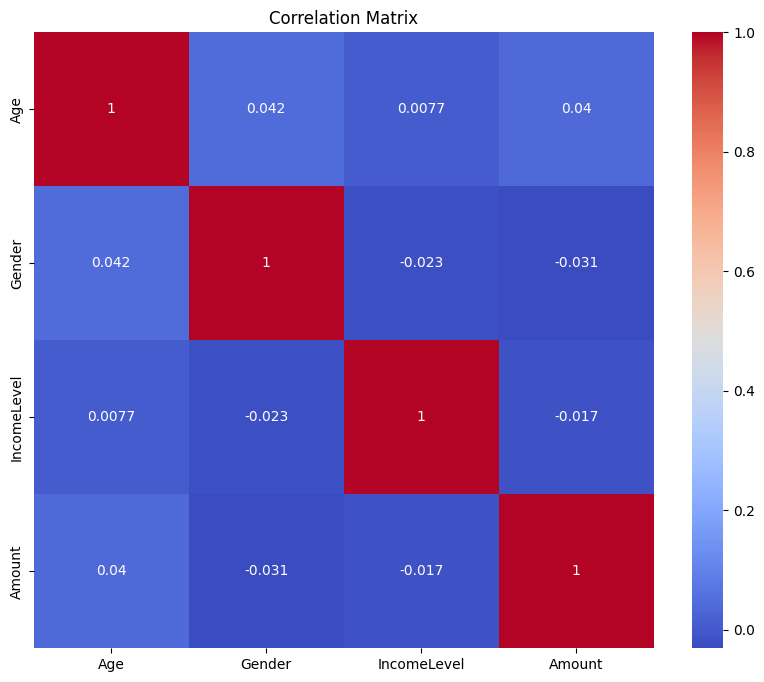

In [ ]:
import pandas as pd

# Load the datasets
customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

# Merge datasets on CustomerID
merged_data = pd.merge(customer_demographics, customer_transactions, on='CustomerID', how='inner')
merged_data = pd.merge(merged_data, socmed_interactions, on='CustomerID', how='inner')

# Clean data: Drop or fill missing values as needed
merged_data = merged_data.dropna()  # Alternatively, you can use merged_data.fillna() if you have specific values to fill.

# Convert categorical columns using one-hot encoding or label encoding
merged_data['Gender'] = merged_data['Gender'].map({'Male': 1, 'Female': 0})
merged_data['IncomeLevel'] = merged_data['IncomeLevel'].map({'Low': 1, 'Medium': 2, 'High': 3})

# Example for creating numeric values from platforms and interaction types
merged_data['Platform'] = merged_data['Platform'].astype('category').cat.codes
merged_data['InteractionType'] = merged_data['InteractionType'].astype('category').cat.codes

# Select numerical columns
numerical_cols = merged_data.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numerical_cols.corr()

# Display correlation matrix
print(correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap for visualizing correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


The correlation matrix heatmap provides insights into the relationships between different numerical variables in your dataset. Here’s how to interpret it:

Key Observations:
- Age and Amount:
  - Correlation coefficient: 0.04
  - Interpretation: There is a very weak positive correlation between age and the amount spent. This suggests that age has little to no effect on how much a customer spends.

- Gender and Amount:
  - Correlation coefficient: -0.031
  - Interpretation: There is a very weak negative correlation between gender and the amount spent. Since the value is close to 0, it indicates that gender does not significantly impact spending behavior. However, slight tendencies might exist, but they are minimal.

- IncomeLevel and Amount:
  - Correlation coefficient: -0.017
  - Interpretation: The correlation between income level and amount spent is also very weak and slightly negative. This indicates that income level doesn’t play a major role in determining the amount a customer spends, at least within the scope of this data.

- Gender and IncomeLevel:
  - Correlation coefficient: -0.023
  - Interpretation: There is a very weak negative correlation between gender and income level. This implies that income level distribution is relatively similar across genders.

- General Observation:
  - All correlations are very close to 0, indicating weak or no clear linear relationships between these variables. This might mean that factors other than age, gender, and income level drive spending patterns, or there could be more nuanced interactions not captured here.


                 DaysSinceSignup  SignupYear
DaysSinceSignup         1.000000   -0.962858
SignupYear             -0.962858    1.000000


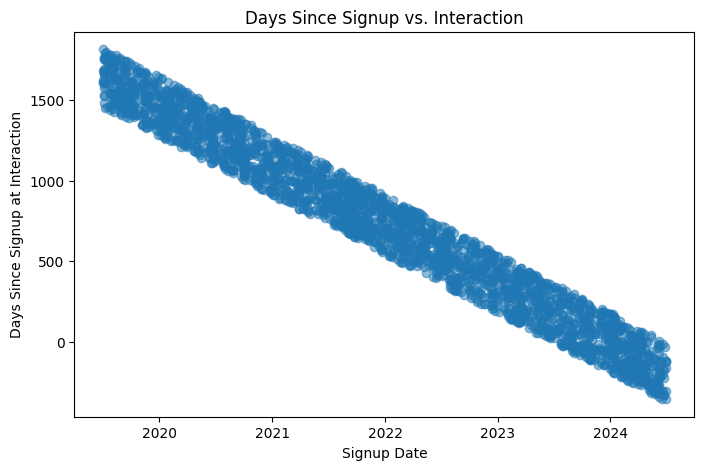

In [ ]:
# Merge the demographics and social media datasets on CustomerID
merged_demo_socmed = pd.merge(customer_demographics, socmed_interactions, on='CustomerID', how='inner')

# Convert 'SignupDate' and 'InteractionDate' to datetime format
merged_demo_socmed['SignupDate'] = pd.to_datetime(merged_demo_socmed['SignupDate'])
merged_demo_socmed['InteractionDate'] = pd.to_datetime(merged_demo_socmed['InteractionDate'])

# Create new features:
# 1. 'DaysSinceSignup' - difference between interaction date and signup date
merged_demo_socmed['DaysSinceSignup'] = (merged_demo_socmed['InteractionDate'] - merged_demo_socmed['SignupDate']).dt.days

# 2. 'SignupYear' - to analyze sign-up trends by year
merged_demo_socmed['SignupYear'] = merged_demo_socmed['SignupDate'].dt.year

# Drop or handle missing values if any
merged_demo_socmed = merged_demo_socmed.dropna(subset=['DaysSinceSignup', 'SignupYear'])

# Extract relevant columns to analyze correlation
corr_columns = merged_demo_socmed[['DaysSinceSignup', 'SignupYear']]

# Calculate the correlation
correlation = corr_columns.corr()

print(correlation)

import matplotlib.pyplot as plt

# Scatter plot: Days since signup vs. Interaction date
plt.figure(figsize=(8, 5))
plt.scatter(merged_demo_socmed['SignupDate'], merged_demo_socmed['DaysSinceSignup'], alpha=0.5)
plt.xlabel('Signup Date')
plt.ylabel('Days Since Signup at Interaction')
plt.title('Days Since Signup vs. Interaction')
plt.show()



Number of customers who interacted on social media before signing up: 297
Percentage of customers who interacted on social media before signing up: 17.78%
Platform
Twitter          93
Facebook         86
Instagram        86
Uncategorized    32
Name: count, dtype: int64
InteractionType
Share      104
Comment     99
Like        94
Name: count, dtype: int64


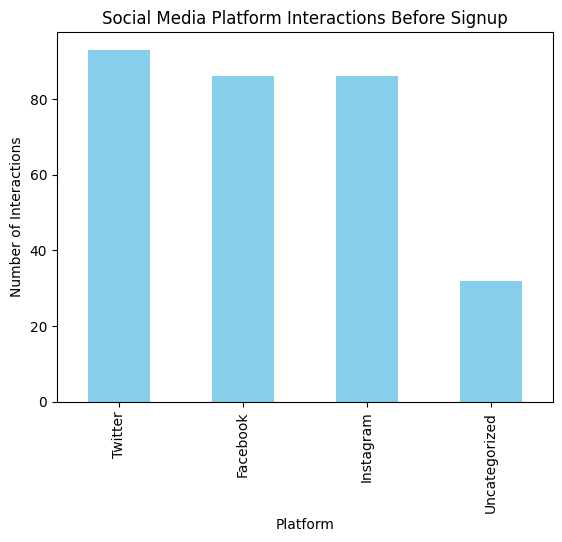

In [ ]:
# Add a column to indicate if the interaction happened before the signup
merged_demo_socmed['InteractionBeforeSignup'] = merged_demo_socmed['InteractionDate'] < merged_demo_socmed['SignupDate']

# Check the count of customers who interacted on social media before signing up
before_signup_count = merged_demo_socmed['InteractionBeforeSignup'].sum()
print(f"Number of customers who interacted on social media before signing up: {before_signup_count}")

# Get percentage
total_customers = merged_demo_socmed['CustomerID'].nunique()
percentage_before_signup = (before_signup_count / total_customers) * 100
print(f"Percentage of customers who interacted on social media before signing up: {percentage_before_signup:.2f}%")

# Filter customers who interacted before signing up
customers_before_signup = merged_demo_socmed[merged_demo_socmed['InteractionBeforeSignup']]

# Look for trends: e.g., by platform, interaction type, or sentiment
platform_trends = customers_before_signup['Platform'].value_counts()
interaction_type_trends = customers_before_signup['InteractionType'].value_counts()

print(platform_trends)
print(interaction_type_trends)

import matplotlib.pyplot as plt

# Bar chart for platforms where interaction occurred before signup
platform_trends.plot(kind='bar', color='skyblue')
plt.title('Social Media Platform Interactions Before Signup')
plt.xlabel('Platform')
plt.ylabel('Number of Interactions')
plt.show()



Number of Customers:
- 297 customers interacted on social media before signing up, which represents 17.78% of the total customer base.
- Interpretation: Social media interactions are a notable source of engagement that leads to signups, suggesting it is an effective channel for customer acquisition. However, it’s not the primary driver, as less than 20% of customers had prior interactions.

Platform Analysis:
- Twitter (93 interactions): Most common platform for pre-signup interactions.
- Facebook (86 interactions): Second most common, almost equal to Instagram.
- Instagram (86 interactions): Tied with Facebook, showing strong engagement.
- Uncategorized (32 interactions): These might represent platforms not explicitly categorized or tracked.
- Interpretation: Twitter appears to be the most effective platform in engaging potential customers before they sign up. This could indicate that marketing strategies or campaigns on Twitter are driving more awareness or engagement. Facebook and Instagram also show significant activity, indicating a balanced approach across these social platforms.

Interaction Type Analysis:
- Shares (104): Most common type of interaction leading to signups.
- Comments (99): Close behind, showing that discussions or feedback are also - engaging potential customers.
- Likes (94): Slightly less common but still significant.

Interpretation: Sharing content is the most effective interaction type in converting social media users to customers. This suggests that content that encourages users to share—such as promotions, contests, or engaging posts—could be particularly effective. Comments also play a major role, likely indicating users seeking more information or engaging in discussions.

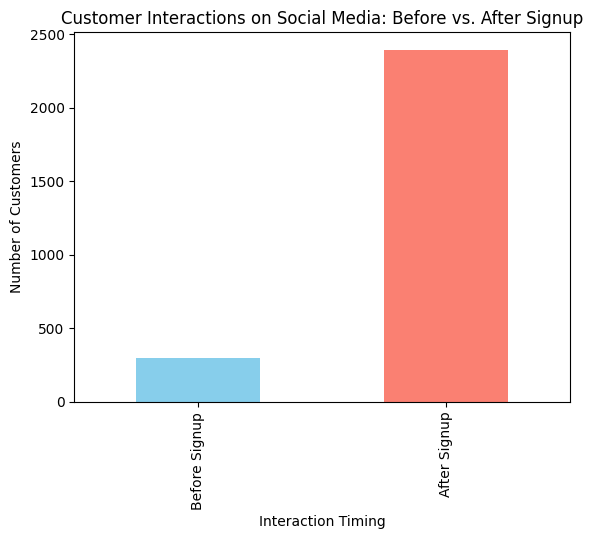

In [ ]:
import matplotlib.pyplot as plt

# Count customers who interacted before and after signup
before_signup = merged_demo_socmed['InteractionBeforeSignup'].sum()
after_signup = len(merged_demo_socmed) - before_signup

# Create a DataFrame for easy plotting
interaction_data = pd.DataFrame({
    'Type': ['Before Signup', 'After Signup'],
    'Count': [before_signup, after_signup]
})

# Plotting the stacked bar chart
interaction_data.plot(kind='bar', x='Type', y='Count', color=['skyblue', 'salmon'], legend=False)
plt.title('Customer Interactions on Social Media: Before vs. After Signup')
plt.xlabel('Interaction Timing')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# Merge demographics and social media datasets to identify who interacted first
merged_demo_socmed = pd.merge(customer_demographics, socmed_interactions, on='CustomerID', how='inner')

# Convert dates to datetime format
merged_demo_socmed['SignupDate'] = pd.to_datetime(merged_demo_socmed['SignupDate'])
merged_demo_socmed['InteractionDate'] = pd.to_datetime(merged_demo_socmed['InteractionDate'])
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Identify if interaction happened before signup
merged_demo_socmed['InteractionBeforeSignup'] = merged_demo_socmed['InteractionDate'] < merged_demo_socmed['SignupDate']

# Filter those who interacted before signing up
interacted_before_signup = merged_demo_socmed[merged_demo_socmed['InteractionBeforeSignup']]

# Merge with customer transactions to see if they made a purchase after signing up
merged_all = pd.merge(interacted_before_signup, customer_transactions, on='CustomerID', how='inner')

# Filter for transactions that happened after the signup date
valid_customers = merged_all[merged_all['TransactionDate'] > merged_all['SignupDate']]

# Number of unique customers who met all criteria
num_valid_customers = valid_customers['CustomerID'].nunique()
print(f"Number of customers who interacted first, signed up, and then bought: {num_valid_customers}")

# Breakdown by social media platform
platform_breakdown = valid_customers['Platform'].value_counts()
print(platform_breakdown)

# Breakdown by interaction type
interaction_type_breakdown = valid_customers['InteractionType'].value_counts()
print(interaction_type_breakdown)



Number of customers who interacted first, signed up, and then bought: 42
Platform
Twitter          22
Facebook         19
Instagram        15
Uncategorized     7
Name: count, dtype: int64
InteractionType
Like       28
Comment    18
Share      17
Name: count, dtype: int64


Customer ID Overlap Analysis:
                         Category  Count
0            Only in Demographics    367
1            Only in Social Media     90
2            Only in Transactions     89
3          In Demo & Social Media    622
4          In Demo & Transactions    601
5  In Social Media & Transactions    133
6                    In All Three   1048


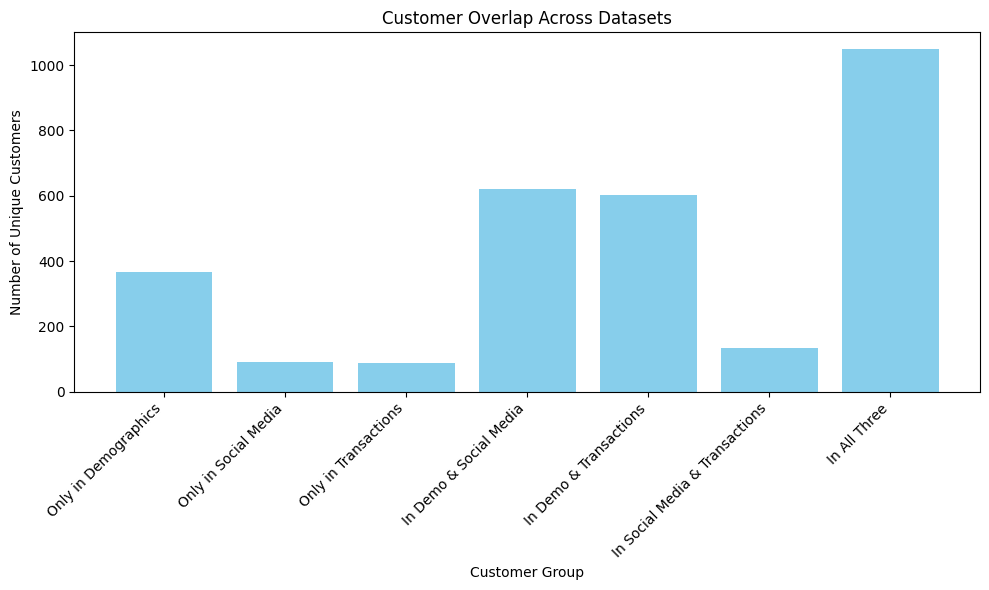


Most Common Customer Journeys:
JourneyType
Signup -> Transaction -> Interaction    716
Signup -> Interaction                   571
Signup -> Transaction                   487
Signup                                  367
Signup -> Interaction -> Transaction    347
Transaction -> Signup                   154
Transaction -> Signup -> Interaction    150
Interaction -> Transaction              133
Transaction -> Interaction -> Signup     99
Interaction                              90
Transaction                              89
Interaction -> Signup                    75
Interaction -> Signup -> Transaction     42
Interaction -> Transaction -> Signup     36
Name: count, dtype: int64


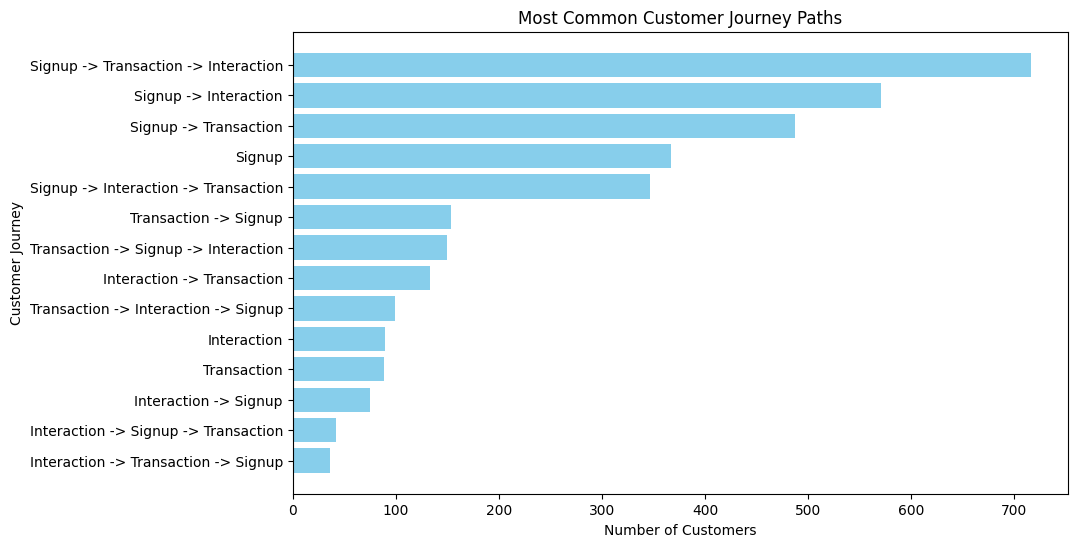

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming datasets are loaded: customer_demographics, socmed_interactions, customer_transactions

# Ensure date columns are parsed correctly
customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'], errors='coerce')
socmed_interactions['InteractionDate'] = pd.to_datetime(socmed_interactions['InteractionDate'], errors='coerce')
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], errors='coerce')

# Step 1: Analyze Customer ID Overlaps

# Get unique Customer IDs from each dataset
demographics_customers = set(customer_demographics['CustomerID'].unique())
social_media_customers = set(socmed_interactions['CustomerID'].unique())
transaction_customers = set(customer_transactions['CustomerID'].unique())

# Count unique customers in each dataset
only_in_demographics = len(demographics_customers - social_media_customers - transaction_customers)
only_in_social_media = len(social_media_customers - demographics_customers - transaction_customers)
only_in_transactions = len(transaction_customers - demographics_customers - social_media_customers)

# Count overlaps
in_demo_and_socmed = len(demographics_customers & social_media_customers - transaction_customers)
in_demo_and_transactions = len(demographics_customers & transaction_customers - social_media_customers)
in_socmed_and_transactions = len(social_media_customers & transaction_customers - demographics_customers)

# Count customers present in all three datasets
in_all_three = len(demographics_customers & social_media_customers & transaction_customers)

# Prepare data for plotting
overlap_data = {
    'Only in Demographics': only_in_demographics,
    'Only in Social Media': only_in_social_media,
    'Only in Transactions': only_in_transactions,
    'In Demo & Social Media': in_demo_and_socmed,
    'In Demo & Transactions': in_demo_and_transactions,
    'In Social Media & Transactions': in_socmed_and_transactions,
    'In All Three': in_all_three
}

# Convert to a DataFrame for easy plotting
overlap_df = pd.DataFrame(list(overlap_data.items()), columns=['Category', 'Count'])

# Print the counts for verification
print("Customer ID Overlap Analysis:")
print(overlap_df)

# Bar Chart Visualization
plt.figure(figsize=(10, 6))
plt.bar(overlap_df['Category'], overlap_df['Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Customer Overlap Across Datasets')
plt.xlabel('Customer Group')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()

# Step 2: Classify and Visualize Customer Journeys

# Merge all datasets to get full information
merged_demo_socmed = pd.merge(customer_demographics, socmed_interactions, on='CustomerID', how='outer')
merged_all = pd.merge(merged_demo_socmed, customer_transactions, on='CustomerID', how='outer')

# Create a DataFrame that captures the first event date for each type
merged_all['FirstEvent'] = merged_all[['InteractionDate', 'SignupDate', 'TransactionDate']].min(axis=1)

# Function to classify the customer journey
def classify_journey(row):
    events = {
        'Interaction': row['InteractionDate'],
        'Signup': row['SignupDate'],
        'Transaction': row['TransactionDate']
    }

    # Sort the events by date to determine the order
    sorted_events = sorted(events.items(), key=lambda x: (x[1], x[0]))  # Sort by date, then by event type
    # Get only those events that are not null
    ordered_events = [event[0] for event in sorted_events if pd.notna(event[1])]

    # Return the journey as a string
    return ' -> '.join(ordered_events)

# Apply the function to classify the journey of each customer
merged_all['JourneyType'] = merged_all.apply(classify_journey, axis=1)

# Count the occurrences of each journey type, making sure it's unique Customer IDs
unique_journey_counts = merged_all[['CustomerID', 'JourneyType']].drop_duplicates()
journey_counts = unique_journey_counts['JourneyType'].value_counts()

# Print journey counts for verification
print("\nMost Common Customer Journeys:")
print(journey_counts)

# Visualization of Journey Counts
journey_counts_df = journey_counts.reset_index()
journey_counts_df.columns = ['Journey', 'Count']

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(journey_counts_df['Journey'], journey_counts_df['Count'], color='skyblue')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Journey')
plt.title('Most Common Customer Journey Paths')
plt.gca().invert_yaxis()  # Invert to show the most common journey at the top
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Assuming datasets are loaded: customer_demographics, socmed_interactions, customer_transactions

# Ensure date columns are parsed correctly
customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'], errors='coerce')
socmed_interactions['InteractionDate'] = pd.to_datetime(socmed_interactions['InteractionDate'], errors='coerce')
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], errors='coerce')

# Step 1: Analyze Customer ID Overlaps

# Get unique Customer IDs from each dataset
demographics_customers = set(customer_demographics['CustomerID'].unique())
social_media_customers = set(socmed_interactions['CustomerID'].unique())
transaction_customers = set(customer_transactions['CustomerID'].unique())

# Count unique customers in each dataset
only_in_demographics = len(demographics_customers - social_media_customers - transaction_customers)
only_in_social_media = len(social_media_customers - demographics_customers - transaction_customers)
only_in_transactions = len(transaction_customers - demographics_customers - social_media_customers)

# Count overlaps
in_demo_and_socmed = len(demographics_customers & social_media_customers - transaction_customers)
in_demo_and_transactions = len(demographics_customers & transaction_customers - social_media_customers)
in_socmed_and_transactions = len(social_media_customers & transaction_customers - demographics_customers)

# Count customers present in all three datasets
in_all_three = len(demographics_customers & social_media_customers & transaction_customers)

# Prepare data for plotting
overlap_data = {
    'Only in Demographics': only_in_demographics,
    'Only in Social Media': only_in_social_media,
    'Only in Transactions': only_in_transactions,
    'In Demo & Social Media': in_demo_and_socmed,
    'In Demo & Transactions': in_demo_and_transactions,
    'In Social Media & Transactions': in_socmed_and_transactions,
    'In All Three': in_all_three
}

# Convert to a DataFrame for easy plotting
overlap_df = pd.DataFrame(list(overlap_data.items()), columns=['Category', 'Count'])

# Print the counts for verification
print("Customer ID Overlap Analysis:")
print(overlap_df)

# Bar Chart Visualization Using Plotly
fig1 = px.bar(overlap_df, x='Category', y='Count', title='Customer Overlap Across Datasets',
              labels={'Category': 'Customer Group', 'Count': 'Number of Unique Customers'},
              color='Category', color_discrete_sequence=px.colors.qualitative.Set2)
fig1.update_layout(xaxis_tickangle=-45)
fig1.show()

# Step 2: Classify and Visualize Customer Journeys

# Merge all datasets to get full information
merged_demo_socmed = pd.merge(customer_demographics, socmed_interactions, on='CustomerID', how='outer')
merged_all = pd.merge(merged_demo_socmed, customer_transactions, on='CustomerID', how='outer')

# Create a DataFrame that captures the first event date for each type
merged_all['FirstEvent'] = merged_all[['InteractionDate', 'SignupDate', 'TransactionDate']].min(axis=1)

# Function to classify the customer journey
def classify_journey(row):
    events = {
        'Interaction': row['InteractionDate'],
        'Signup': row['SignupDate'],
        'Transaction': row['TransactionDate']
    }

    # Sort the events by date to determine the order
    sorted_events = sorted(events.items(), key=lambda x: (x[1], x[0]))  # Sort by date, then by event type
    # Get only those events that are not null
    ordered_events = [event[0] for event in sorted_events if pd.notna(event[1])]

    # Return the journey as a string
    return ' -> '.join(ordered_events)

# Apply the function to classify the journey of each customer
merged_all['JourneyType'] = merged_all.apply(classify_journey, axis=1)

# Count the occurrences of each journey type, making sure it's unique Customer IDs
unique_journey_counts = merged_all[['CustomerID', 'JourneyType']].drop_duplicates()
journey_counts = unique_journey_counts['JourneyType'].value_counts()

# Print journey counts for verification
print("\nMost Common Customer Journeys:")
print(journey_counts)

# Visualization of Journey Counts Using Plotly
journey_counts_df = journey_counts.reset_index()
journey_counts_df.columns = ['Journey', 'Count']

# Create a horizontal bar plot using Plotly
fig2 = px.bar(journey_counts_df, x='Count', y='Journey', orientation='h',
              title='Most Common Customer Journey Paths',
              labels={'Count': 'Number of Customers', 'Journey': 'Customer Journey'},
              color='Journey', color_discrete_sequence=px.colors.qualitative.Set3)
fig2.update_layout(yaxis={'categoryorder':'total ascending'})
fig2.show()


Customer ID Overlap Analysis:
                         Category  Count
0            Only in Demographics    367
1            Only in Social Media     90
2            Only in Transactions     89
3          In Demo & Social Media    622
4          In Demo & Transactions    601
5  In Social Media & Transactions    133
6                    In All Three   1048



Most Common Customer Journeys:
JourneyType
Signup -> Transaction -> Interaction    716
Signup -> Interaction                   571
Signup -> Transaction                   487
Signup                                  367
Signup -> Interaction -> Transaction    347
Transaction -> Signup                   154
Transaction -> Signup -> Interaction    150
Interaction -> Transaction              133
Transaction -> Interaction -> Signup     99
Interaction                              90
Transaction                              89
Interaction -> Signup                    75
Interaction -> Signup -> Transaction     42
Interaction -> Transaction -> Signup     36
Name: count, dtype: int64


### Interpretation of Customer ID Overlap Analysis:

1. **Only in Demographics (367 customers):**
   - These customers are present only in the demographics dataset. They have signed up, but there are no recorded interactions on social media or transactions. This could mean they haven't engaged much after signing up or are inactive.

2. **Only in Social Media (90 customers):**
   - These customers have only interacted on social media but have not signed up or made any purchases. This group might consist of potential leads who are aware of the brand but haven't converted yet.

3. **Only in Transactions (89 customers):**
   - Customers who have made transactions without being present in the demographics or social media datasets. This could indicate purchases made as guests, or they are recorded without prior engagement or sign-up.

4. **In Demographics & Social Media (622 customers):**
   - Customers who are signed up (present in demographics) and have interacted on social media. They are engaged but may not have completed a transaction yet. They might be future potential buyers or users who need more nurturing.

5. **In Demographics & Transactions (601 customers):**
   - These customers have signed up and made purchases but haven't interacted on social media. They might be more traditional buyers or simply less active on social platforms.

6. **In Social Media & Transactions (133 customers):**
   - Customers who have engaged on social media and completed a transaction but are not recorded in the demographics dataset. This might indicate they made purchases without signing up or interacted in ways not tied to their signup information.

7. **In All Three (1048 customers):**
   - The largest group, these customers have signed up, interacted on social media, and made purchases. They are highly engaged, showing strong customer loyalty and complete engagement across the brand's touchpoints.

### Interpretation of Most Common Customer Journeys:

1. **"Signup -> Transaction -> Interaction" (716 customers):**
   - This is the most common journey, where customers sign up, make a purchase, and then engage on social media. This suggests that after completing a purchase, many customers reach out to engage or express their feedback, possibly leaving reviews or sharing their experience.

2. **"Signup -> Interaction" (571 customers):**
   - Customers who signed up and then engaged on social media without making a purchase. They might be leads who are in the consideration phase, interacting for more information or exploring the brand further.

3. **"Signup -> Transaction" (487 customers):**
   - These customers signed up and made a purchase without prior social media interaction. This indicates a straightforward conversion path, perhaps due to effective onboarding, targeted marketing, or an already established brand presence.

4. **"Signup" (367 customers):**
   - Customers who signed up but did not make a purchase or interact on social media. This group represents potential customers who could be targeted for future marketing efforts to convert them into active buyers.

5. **"Signup -> Interaction -> Transaction" (347 customers):**
   - Customers who signed up, interacted on social media, and then made a purchase. These customers might have sought more information or assurance via social channels before deciding to buy, indicating the role of social engagement in conversion.

6. **Other Journeys (e.g., "Transaction -> Signup," "Interaction -> Transaction"):**
   - Less common paths include customers who interacted or made a purchase before signing up. These might indicate users engaging through guest checkouts or ad-hoc interactions that led them to eventually sign up.
   - Customers starting with "Interaction" indicate the role of social media as an entry point to the brand, potentially converting them into signups and buyers.

### Overall Insights:
- **Engagement Across Channels:**
  - The significant count of customers in the "In All Three" group shows that a well-rounded engagement strategy across signup, social media, and transactions is effective for nurturing customer relationships.
- **Conversion Pathways:**
  - Many customers proceed directly from signup to purchase without engaging on social media, highlighting that targeted marketing or a seamless onboarding process can lead to quick conversions.
  - Social media serves both as an entry point and a post-purchase engagement tool, suggesting it’s crucial for maintaining customer relationships and influencing decision-making.
- **Opportunity for Growth:**
  - Efforts could be directed towards converting customers who have signed up or interacted without making a purchase. Engaging content, offers, or retargeting campaigns can help drive this group toward completing transactions.

These insights help you understand where to focus marketing strategies, how to optimize the customer journey, and where there may be opportunities to boost engagement and conversion.

In [ ]:
import pandas as pd
import plotly.express as px

# Assuming datasets are loaded: customer_demographics, socmed_interactions, customer_transactions

# Ensure date columns are parsed correctly
customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'], errors='coerce')
socmed_interactions['InteractionDate'] = pd.to_datetime(socmed_interactions['InteractionDate'], errors='coerce')
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'], errors='coerce')

# Step 1: Identify Customers Present in All Three Datasets
demographics_customers = set(customer_demographics['CustomerID'].unique())
social_media_customers = set(socmed_interactions['CustomerID'].unique())
transaction_customers = set(customer_transactions['CustomerID'].unique())

# Customers present in all three datasets
customers_in_all_three = demographics_customers & social_media_customers & transaction_customers

# Step 2: Merge All Data to Classify Journeys
merged_demo_socmed = pd.merge(customer_demographics, socmed_interactions, on='CustomerID', how='inner')
merged_all = pd.merge(merged_demo_socmed, customer_transactions, on='CustomerID', how='inner')

# Filter to only include customers present in all three datasets
merged_all = merged_all[merged_all['CustomerID'].isin(customers_in_all_three)]

# Function to classify the customer journey
def classify_journey(row):
    events = {
        'Interaction': row['InteractionDate'],
        'Signup': row['SignupDate'],
        'Transaction': row['TransactionDate']
    }

    # Sort the events by date to determine the order
    sorted_events = sorted(events.items(), key=lambda x: (x[1], x[0]))  # Sort by date, then by event type
    # Get only those events that are not null
    ordered_events = [event[0] for event in sorted_events if pd.notna(event[1])]

    # Return the journey as a string
    return ' -> '.join(ordered_events)

# Apply the function to classify the journey of each customer
merged_all['JourneyType'] = merged_all.apply(classify_journey, axis=1)

# Count the occurrences of each journey type, making sure it's unique Customer IDs
unique_journey_counts = merged_all[['CustomerID', 'JourneyType']].drop_duplicates()
journey_counts_in_all_three = unique_journey_counts['JourneyType'].value_counts()

# Print journey counts for verification
print("\nMost Common Journeys for Customers in All Three Datasets:")
print(journey_counts_in_all_three)

# Step 3: Create Pie Chart Using Plotly
journey_counts_df = journey_counts_in_all_three.reset_index()
journey_counts_df.columns = ['Journey', 'Count']

# Create a pie chart
fig = px.pie(journey_counts_df, values='Count', names='Journey',
             title='Percentage of Customer Journeys for Those Present in All Three Datasets',
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()



Most Common Journeys for Customers in All Three Datasets:
JourneyType
Signup -> Transaction -> Interaction    716
Signup -> Interaction -> Transaction    347
Transaction -> Signup -> Interaction    150
Transaction -> Interaction -> Signup     99
Interaction -> Signup -> Transaction     42
Interaction -> Transaction -> Signup     36
Name: count, dtype: int64
